# Pruned QAT CNN to hls4ml for `cnn_small_hls_opt_img512`

> Vitis requirement: if you want notebook-driven synthesis, start the Jupyter server from a shell that already ran `source /tools/Xilinx/Vitis/2024.2/.settings64-Vitis.sh` and `source /tools/Xilinx/Vitis_HLS/2024.2/.settings64-Vitis_HLS.sh`, then restart the kernel. A notebook cell like `!source /opt/hdev/cli/enable/vitis` is not enough because it does not modify the long-lived Jupyter server environment.
>
> Example server launch:
> `tmux new-session -d -s jupyter_ml_baseline_8890 "bash -lc 'source /tools/Xilinx/Vitis/2024.2/.settings64-Vitis.sh && source /tools/Xilinx/Vitis_HLS/2024.2/.settings64-Vitis_HLS.sh && cd /mnt/scratch/sdeheredia/Coyote/examples/ml_baseline/hls4ml && exec /mnt/scratch/sdeheredia/Coyote/examples/ml_baseline/.venv/bin/jupyter notebook --no-browser --ip=127.0.0.1 --port=8890 --port-retries=0'"`

This notebook is a linear, notebook-owned workflow for exploring pruned QKeras QAT models and hls4ml settings for the Coyote bitstream classifier.

Run it top-to-bottom to:

1. Build deterministic balanced k-fold splits from the dataset manifests.
2. Train a pruned + QAT QKeras CNN on fold 0 and inspect training/accuracy.
3. Check sparsity.
4. Convert/compile the fold-0 model with hls4ml, inspect the spec, plot the graph, and run bit-accurate emulation.
5. Run representative-fold logic synthesis.
6. Train the remaining folds and produce pooled k-fold plots/metrics for the newly trained notebook model.
7. Convert/emulate all folds and compare pooled QKeras vs hls4ml accuracy.

The notebook does not load old model artifacts. Long-running results are reused only when the current iteration fingerprint matches the saved manifest exactly.

## Imports

In [1]:
%matplotlib inline

import csv
import hashlib
import json
import math
import os
import pprint
import shutil
import subprocess
import sys
import time
from dataclasses import asdict, dataclass
from pathlib import Path

# QKeras 0.9 + hls4ml 1.3 in this workspace expects legacy tf.keras.
os.environ.setdefault("TF_USE_LEGACY_KERAS", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ["PATH"] = os.path.expanduser("~/.local/graphviz/bin") + ":" + os.environ.get("PATH", "")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_model_optimization as tfmot
from IPython.display import Image, display
from sklearn.metrics import accuracy_score, average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from tensorflow_model_optimization.sparsity import keras as sparsity
from tensorflow_model_optimization.python.core.sparsity.keras import pruning_callbacks

WORKSPACE = Path.cwd().resolve()
if WORKSPACE.name != "hls4ml":
    raise RuntimeError(f"Run this notebook from the hls4ml workspace root, got {WORKSPACE}")
EXAMPLE_ROOT = WORKSPACE.parent
for path in (WORKSPACE, EXAMPLE_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

PY_CANDIDATES = [
    EXAMPLE_ROOT / ".venv_hls4ml" / "bin" / "python",
    EXAMPLE_ROOT / ".venv" / "bin" / "python",
    Path(sys.executable),
]
PY = next((path for path in PY_CANDIDATES if path.exists() and os.access(path, os.X_OK)), Path(sys.executable))

print("workspace:", WORKSPACE)
print("python:", PY)
print("tensorflow:", tf.__version__)
print("dot:", shutil.which("dot"))

I0000 00:00:1776993486.508887 2731609 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776993491.454117 2731609 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


workspace: /pub/scratch/sdeheredia/Coyote/examples/ml_baseline/hls4ml
python: /pub/scratch/sdeheredia/Coyote/examples/ml_baseline/.venv_hls4ml/bin/python
tensorflow: 2.21.0
dot: /home/sdeheredia/.local/graphviz/bin/dot


In [2]:
## Check GPUs

In [3]:
import tensorflow as tf
print(tf.config.list_physical_devices("GPU"))

[]


E0000 00:00:1776993495.677283 2731609 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Editable Parameters

In [4]:
# Training/data/model settings change the training fingerprint.
# hls4ml settings below change only the HLS-sweep fingerprint, so you can retune them after training.
ITERATION_NAME = "pruned_qat_w6_a6_s50_rf8"

# Candidate/dataset settings.
CANDIDATE_NAME = "cnn_small_hls_opt_img512"
IMG_SIZE = 512
MIN_RO = 8000
K_FOLDS = 5
PRIMARY_FOLD = 0
SEED = 42
BALANCE_CLASSES = True

# Model architecture. This mirrors SmallCNNHlsOptimized512 by default.
INPUT_SHAPE = (512, 512, 1)
CONV_SPECS = [
    {"filters": 8, "kernel": (5, 5), "strides": (2, 2), "pad": 2, "name": "conv0"},
    {"filters": 16, "kernel": (3, 3), "strides": (1, 1), "pad": 1, "name": "conv1"},
    {"filters": 24, "kernel": (3, 3), "strides": (1, 1), "pad": 1, "name": "conv2"},
    {"filters": 24, "kernel": (3, 3), "strides": (1, 1), "pad": 1, "name": "conv3"},
    {"filters": 32, "kernel": (3, 3), "strides": (1, 1), "pad": 1, "name": "conv4"},
]
FINAL_AVG_POOL = (8, 8)
OUTPUT_UNITS = 1

# QKeras quantization settings.
QUANTIZER_TAG = "w6_a6"
WEIGHT_BITS = 6
WEIGHT_INTEGER = 0
ACTIVATION_BITS = 6
ACTIVATION_INTEGER = [2, 2, 3, 4, 5]
QUANTIZER_ALPHA = 1

# Pruning settings.
PRUNE_FINAL_SPARSITY = 0.5
PRUNE_BEGIN_EPOCH = 2
PRUNE_END_EPOCH = 300
PRUNE_FREQUENCY_EPOCHS = 5
PRUNE_OUTPUT_DENSE = False

# Training settings.
EPOCHS = 300
BATCH_SIZE = 16
METRICS_EVERY_N_EPOCHS = 1
LR = 1e-4
AUGMENT = True
FLIP_H_PROB = 0.5
FLIP_V_PROB = 0.5
CROP_SCALE_MIN = 1.0
TRANSLATE = 0.0
CACHE_DATA = True

# hls4ml settings. These change only the HLS fingerprint/cache, not training.
HLS_BACKEND = "Vitis"
HLS_SWEEP_NAME = "default"
HLS_IO_TYPE = "io_stream"
HLS_STRATEGY = "Latency"
HLS_REUSE_FACTOR = 1
HLS_RESOURCE_STRATEGY_THRESHOLD = 4096
HLS_RESOURCE_STRATEGY = "Resource"
HLS_CLOCK_PERIOD = 5.0
HLS_PART = "xcu55c-fsvh2892-2L-e"
HLS_OUTPUT_PRECISION = None
HLS_POOL_ACCUM_PRECISION = None
HLS_ACCUM_PRECISION = None
N_EMULATION_SAMPLES = None  # None means the full validation fold.
N_LAYER_TRACE_SAMPLES = 4  # Keep layer tracing bounded; set to None to trace the full emulation set.
SYNTHESIS_FOLDS = [PRIMARY_FOLD]  # Representative-fold synthesis by default.

TRAINING_CONFIG = {
    "iteration_name": ITERATION_NAME,
    "candidate_name": CANDIDATE_NAME,
    "img_size": IMG_SIZE,
    "min_ro": MIN_RO,
    "k_folds": K_FOLDS,
    "primary_fold": PRIMARY_FOLD,
    "seed": SEED,
    "balance_classes": BALANCE_CLASSES,
    "input_shape": INPUT_SHAPE,
    "conv_specs": CONV_SPECS,
    "final_avg_pool": FINAL_AVG_POOL,
    "output_units": OUTPUT_UNITS,
    "quantizer_tag": QUANTIZER_TAG,
    "weight_bits": WEIGHT_BITS,
    "weight_integer": WEIGHT_INTEGER,
    "activation_bits": ACTIVATION_BITS,
    "activation_integer": ACTIVATION_INTEGER,
    "quantizer_alpha": QUANTIZER_ALPHA,
    "prune_final_sparsity": PRUNE_FINAL_SPARSITY,
    "prune_begin_epoch": PRUNE_BEGIN_EPOCH,
    "prune_end_epoch": PRUNE_END_EPOCH,
    "prune_frequency_epochs": PRUNE_FREQUENCY_EPOCHS,
    "prune_output_dense": PRUNE_OUTPUT_DENSE,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "metrics_every_n_epochs": METRICS_EVERY_N_EPOCHS,
    "lr": LR,
    "augment": AUGMENT,
    "flip_h_prob": FLIP_H_PROB,
    "flip_v_prob": FLIP_V_PROB,
    "crop_scale_min": CROP_SCALE_MIN,
    "translate": TRANSLATE,
    "cache_data": CACHE_DATA,
}

HLS_CONFIG = {
    "hls_backend": HLS_BACKEND,
    "hls_sweep_name": HLS_SWEEP_NAME,
    "hls_io_type": HLS_IO_TYPE,
    "hls_strategy": HLS_STRATEGY,
    "hls_reuse_factor": HLS_REUSE_FACTOR,
    "hls_resource_strategy_threshold": HLS_RESOURCE_STRATEGY_THRESHOLD,
    "hls_resource_strategy": HLS_RESOURCE_STRATEGY,
    "hls_clock_period": HLS_CLOCK_PERIOD,
    "hls_part": HLS_PART,
    "hls_output_precision": HLS_OUTPUT_PRECISION,
    "hls_pool_accum_precision": HLS_POOL_ACCUM_PRECISION,
    "hls_accum_precision": HLS_ACCUM_PRECISION,
    "n_emulation_samples": N_EMULATION_SAMPLES,
    "n_layer_trace_samples": N_LAYER_TRACE_SAMPLES,
    "synthesis_folds": SYNTHESIS_FOLDS,
}

CONFIG = {
    "training": TRAINING_CONFIG,
    "hls": HLS_CONFIG,
}
CONFIG


{'training': {'iteration_name': 'pruned_qat_w6_a6_s50_rf8',
  'candidate_name': 'cnn_small_hls_opt_img512',
  'img_size': 512,
  'min_ro': 8000,
  'k_folds': 5,
  'primary_fold': 0,
  'seed': 42,
  'balance_classes': True,
  'input_shape': (512, 512, 1),
  'conv_specs': [{'filters': 8,
    'kernel': (5, 5),
    'strides': (2, 2),
    'pad': 2,
    'name': 'conv0'},
   {'filters': 16,
    'kernel': (3, 3),
    'strides': (1, 1),
    'pad': 1,
    'name': 'conv1'},
   {'filters': 24,
    'kernel': (3, 3),
    'strides': (1, 1),
    'pad': 1,
    'name': 'conv2'},
   {'filters': 24,
    'kernel': (3, 3),
    'strides': (1, 1),
    'pad': 1,
    'name': 'conv3'},
   {'filters': 32,
    'kernel': (3, 3),
    'strides': (1, 1),
    'pad': 1,
    'name': 'conv4'}],
  'final_avg_pool': (8, 8),
  'output_units': 1,
  'quantizer_tag': 'w6_a6',
  'weight_bits': 6,
  'weight_integer': 0,
  'activation_bits': 6,
  'activation_integer': [2, 2, 3, 4, 5],
  'quantizer_alpha': 1,
  'prune_final_sparsit

## Helpers: Fingerprints, Dataset Splits, and Artifacts

In [5]:
from dataset import bitstream_to_array, load_manifest
from train import compute_metrics_from_outputs, save_checkpoint_plots
from pipeline.evaluation import write_metrics_summary
from pipeline.qkeras_plots import (
    build_run_params,
    build_split_info,
    history_rows_to_columns,
    load_final_metrics,
    write_fold_plots,
    write_kfold_plots,
)
from pipeline.qkeras_qat import (
    BitstreamKerasSequence,
    QATTrainConfig,
    apply_numpy_augmentation,
    history_row,
    metrics_from_logits,
    predict_sequence,
    qkeras_per_sample_rows,
    sample_to_nhwc,
    write_history,
    write_qkeras_per_sample,
)

SOURCE_FILES_FOR_FINGERPRINT = [
    EXAMPLE_ROOT / "dataset.py",
    EXAMPLE_ROOT / "model.py",
    EXAMPLE_ROOT / "train.py",
    WORKSPACE / "pipeline" / "qkeras_qat.py",
    WORKSPACE / "pipeline" / "qkeras_plots.py",
]


def file_sha256(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


def canonical_json(payload) -> str:
    return json.dumps(payload, sort_keys=True, separators=(",", ":"), default=str)


SOURCE_HASHES = {str(path.relative_to(WORKSPACE.parent)): file_sha256(path) for path in SOURCE_FILES_FOR_FINGERPRINT if path.exists()}
TRAINING_FINGERPRINT_PAYLOAD = {"training_config": TRAINING_CONFIG, "source_hashes": SOURCE_HASHES}
TRAINING_FINGERPRINT = hashlib.sha256(canonical_json(TRAINING_FINGERPRINT_PAYLOAD).encode()).hexdigest()
TRAINING_SHORT_FINGERPRINT = TRAINING_FINGERPRINT[:12]

HLS_FINGERPRINT_PAYLOAD = {
    "training_fingerprint": TRAINING_FINGERPRINT,
    "hls_config": HLS_CONFIG,
    "source_hashes": SOURCE_HASHES,
}
HLS_FINGERPRINT = hashlib.sha256(canonical_json(HLS_FINGERPRINT_PAYLOAD).encode()).hexdigest()
HLS_SHORT_FINGERPRINT = HLS_FINGERPRINT[:12]
HLS_SWEEP_LABEL = "".join(ch if ch.isalnum() or ch in {"-", "_"} else "_" for ch in HLS_SWEEP_NAME).strip("_") or "default"

# Backward-compatible shorthand for training-root artifacts.
FINGERPRINT = TRAINING_FINGERPRINT
SHORT_FINGERPRINT = TRAINING_SHORT_FINGERPRINT

ITERATION_ROOT = WORKSPACE / "artifacts" / CANDIDATE_NAME / "notebook_pruned_qat" / f"{ITERATION_NAME}_{TRAINING_SHORT_FINGERPRINT}"
ITERATION_ROOT.mkdir(parents=True, exist_ok=True)
MANIFEST_PATH = ITERATION_ROOT / "iteration_manifest.json"

HLS_SWEEP_ROOT = ITERATION_ROOT / "hls_sweeps" / f"{HLS_SWEEP_LABEL}_hls_{HLS_SHORT_FINGERPRINT}"
HLS_SWEEP_ROOT.mkdir(parents=True, exist_ok=True)
HLS_SWEEP_MANIFEST_PATH = HLS_SWEEP_ROOT / "hls_sweep_manifest.json"

manifest = {
    "training_fingerprint": TRAINING_FINGERPRINT,
    "training_short_fingerprint": TRAINING_SHORT_FINGERPRINT,
    "created_or_reused_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "training_config": TRAINING_CONFIG,
    "source_hashes": SOURCE_HASHES,
}
if MANIFEST_PATH.exists():
    old_manifest = json.loads(MANIFEST_PATH.read_text())
    if old_manifest.get("training_fingerprint") != TRAINING_FINGERPRINT:
        raise RuntimeError(f"Fingerprint collision/stale manifest in {ITERATION_ROOT}")
MANIFEST_PATH.write_text(json.dumps(manifest, indent=2, sort_keys=True))

hls_sweep_manifest = {
    "training_fingerprint": TRAINING_FINGERPRINT,
    "hls_fingerprint": HLS_FINGERPRINT,
    "hls_sweep_label": HLS_SWEEP_LABEL,
    "training_root": str(ITERATION_ROOT),
    "hls_sweep_root": str(HLS_SWEEP_ROOT),
    "created_or_reused_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "hls_config": HLS_CONFIG,
    "source_hashes": SOURCE_HASHES,
}
if HLS_SWEEP_MANIFEST_PATH.exists():
    old_hls_manifest = json.loads(HLS_SWEEP_MANIFEST_PATH.read_text())
    if old_hls_manifest.get("hls_fingerprint") != HLS_FINGERPRINT:
        raise RuntimeError(f"Fingerprint collision/stale HLS sweep manifest in {HLS_SWEEP_ROOT}")
HLS_SWEEP_MANIFEST_PATH.write_text(json.dumps(hls_sweep_manifest, indent=2, sort_keys=True))

print("training root:", ITERATION_ROOT)
print("training fingerprint:", TRAINING_FINGERPRINT)
print("hls sweep root:", HLS_SWEEP_ROOT)
print("hls fingerprint:", HLS_FINGERPRINT)


training root: /pub/scratch/sdeheredia/Coyote/examples/ml_baseline/hls4ml/artifacts/cnn_small_hls_opt_img512/notebook_pruned_qat/pruned_qat_w6_a6_s50_rf8_0cfa065db9d4
training fingerprint: 0cfa065db9d45e24d1cfbb0417fe9c4b5384f6e503273f174c064817881601c2
hls sweep root: /pub/scratch/sdeheredia/Coyote/examples/ml_baseline/hls4ml/artifacts/cnn_small_hls_opt_img512/notebook_pruned_qat/pruned_qat_w6_a6_s50_rf8_0cfa065db9d4/hls_sweeps/hls_b1649c98dace
hls fingerprint: b1649c98dace9076b975486c2680b292dd1d6ca71d530fe1f81168a4eaf76624


In [6]:
def load_balanced_samples_from_manifest(min_ro: int, seed: int, balance: bool) -> list[dict]:
    samples = load_manifest(min_ro=min_ro)
    labels = [int(s["class_label"]) for s in samples]
    n_benign = sum(label == 0 for label in labels)
    n_stand = sum(label == 1 for label in labels)
    if not balance or n_benign <= n_stand:
        return samples
    rng = np.random.RandomState(seed)
    benign_samples = [s for s in samples if int(s["class_label"]) == 0]
    stand_samples = [s for s in samples if int(s["class_label"]) == 1]
    benign_keep = rng.choice(len(benign_samples), size=n_stand, replace=False)
    benign_samples = [benign_samples[i] for i in sorted(benign_keep)]
    return benign_samples + stand_samples


def make_kfold_splits(samples: list[dict], k_folds: int, seed: int) -> list[tuple[list[dict], list[dict]]]:
    labels = np.asarray([int(s["class_label"]) for s in samples])
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)
    splits = []
    for train_idx, val_idx in skf.split(samples, labels):
        splits.append(([samples[i] for i in train_idx], [samples[i] for i in val_idx]))
    return splits


def class_counts(rows: list[dict]) -> dict[int, int]:
    return {label: sum(int(row["class_label"]) == label for row in rows) for label in (0, 1)}


samples = load_balanced_samples_from_manifest(MIN_RO, SEED, BALANCE_CLASSES)
splits = make_kfold_splits(samples, K_FOLDS, SEED)

split_rows = []
for fold, (train_samples, val_samples) in enumerate(splits):
    split_rows.append({
        "fold": fold,
        "n_train": len(train_samples),
        "train_benign": class_counts(train_samples)[0],
        "train_standalone": class_counts(train_samples)[1],
        "n_val": len(val_samples),
        "val_benign": class_counts(val_samples)[0],
        "val_standalone": class_counts(val_samples)[1],
    })

split_df = pd.DataFrame(split_rows)
display(split_df)
print("pooled samples:", len(samples), class_counts(samples))

# Persist the exact split for auditability.
split_dir = ITERATION_ROOT / "splits"
split_dir.mkdir(exist_ok=True)
for fold, (train_samples, val_samples) in enumerate(splits):
    for name, rows in [("train", train_samples), ("val", val_samples)]:
        with (split_dir / f"fold_{fold}_{name}.csv").open("w", newline="") as handle:
            fieldnames = sorted({key for row in rows for key in row.keys()})
            writer = csv.DictWriter(handle, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(rows)

,fold,n_train,train_benign,train_standalone,n_val,val_benign,val_standalone
0,0,190,95,95,48,24,24
1,1,190,95,95,48,24,24
2,2,190,95,95,48,24,24
3,3,191,95,96,47,24,23
4,4,191,96,95,47,23,24


pooled samples: 238 {0: 119, 1: 119}


## Helpers: QKeras Model, Pruning, Training, and Metrics

In [7]:
from qkeras import QActivation, QConv2D, QDense
from qkeras.utils import _add_supported_quantized_objects


def weight_quantizer() -> str:
    return f"quantized_bits({WEIGHT_BITS},{WEIGHT_INTEGER},alpha={QUANTIZER_ALPHA})"


def activation_quantizer(block_idx: int) -> str:
    return f"quantized_relu({ACTIVATION_BITS},{ACTIVATION_INTEGER[block_idx]})"


def build_qkeras_notebook_model(name_suffix: str = ""):
    layers = tf.keras.layers
    models = tf.keras.models
    x = x_in = layers.Input(shape=INPUT_SHAPE, name="bitstream_input")
    for i, spec in enumerate(CONV_SPECS):
        x = layers.ZeroPadding2D(padding=spec["pad"], name=f"pad_{spec['name']}")(x)
        x = QConv2D(
            spec["filters"],
            kernel_size=spec["kernel"],
            strides=spec["strides"],
            padding="valid",
            kernel_quantizer=weight_quantizer(),
            bias_quantizer=weight_quantizer(),
            kernel_initializer="lecun_uniform",
            use_bias=True,
            name=spec["name"],
        )(x)
        x = QActivation(activation_quantizer(i), name=f"act{i}")(x)
        x = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), name=f"pool{i}")(x)
    x = layers.AveragePooling2D(pool_size=FINAL_AVG_POOL, strides=FINAL_AVG_POOL, name="gap")(x)
    x = layers.Flatten(name="flatten")(x)
    x = QDense(
        OUTPUT_UNITS,
        kernel_quantizer=weight_quantizer(),
        bias_quantizer=weight_quantizer(),
        kernel_initializer="lecun_uniform",
        use_bias=True,
        name="output_dense",
    )(x)
    return models.Model(inputs=[x_in], outputs=[x], name=f"qkeras_pruned_qat_{QUANTIZER_TAG}{name_suffix}")


qmodel_template = build_qkeras_notebook_model()
qmodel_template.summary()

try:
    from qkeras.autoqkeras.utils import print_qmodel_summary
    print_qmodel_summary(qmodel_template)
except Exception as exc:
    print("QKeras quantizer summary unavailable:", exc)

Model: "qkeras_pruned_qat_w6_a6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bitstream_input (InputLaye  [(None, 512, 512, 1)]     0         
 r)                                                              
                                                                 
 pad_conv0 (ZeroPadding2D)   (None, 516, 516, 1)       0         
                                                                 
 conv0 (QConv2D)             (None, 256, 256, 8)       208       
                                                                 
 act0 (QActivation)          (None, 256, 256, 8)       0         
                                                                 
 pool0 (MaxPooling2D)        (None, 128, 128, 8)       0         
                                                                 
 pad_conv1 (ZeroPadding2D)   (None, 130, 130, 8)       0         
                                           

In [8]:
class KerasSequenceAdapter(tf.keras.utils.Sequence):
    def __init__(self, seq, **kwargs):
        super().__init__(**kwargs)
        self.seq = seq

    def __len__(self):
        return len(self.seq)

    def __getitem__(self, idx):
        return self.seq[idx]

    def on_epoch_end(self):
        if hasattr(self.seq, "on_epoch_end"):
            self.seq.on_epoch_end()


def notebook_train_config(fold: int) -> QATTrainConfig:
    return QATTrainConfig(
        candidate_name=CANDIDATE_NAME,
        quantizer_tag=QUANTIZER_TAG,
        fold=fold,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR,
        seed=SEED,
        augment=AUGMENT,
        flip_h_prob=FLIP_H_PROB,
        flip_v_prob=FLIP_V_PROB,
        crop_scale_min=CROP_SCALE_MIN,
        translate=TRANSLATE,
        cache_data=CACHE_DATA,
        gradcam=False,
    )


@dataclass(frozen=True)
class NotebookCandidate:
    name: str = CANDIDATE_NAME
    model: str = CANDIDATE_NAME
    representation: str = "2d"
    img_size: int = IMG_SIZE
    sequence_length: int = IMG_SIZE * IMG_SIZE
    min_ro: int = MIN_RO
    target_part: str = HLS_PART
    folds: tuple[int, ...] = tuple(range(K_FOLDS))


candidate = NotebookCandidate()


def make_notebook_sequences(fold: int):
    train_samples, val_samples = splits[fold]
    cfg = notebook_train_config(fold)
    train_seq = BitstreamKerasSequence(train_samples, candidate, cfg, shuffle=True, augment=AUGMENT)
    val_seq = BitstreamKerasSequence(val_samples, candidate, cfg, shuffle=False, augment=False)
    aug_val_seq = BitstreamKerasSequence(val_samples, candidate, cfg, shuffle=False, augment=AUGMENT)
    return cfg, train_seq, val_seq, aug_val_seq, train_samples, val_samples


def prune_function_factory(nsteps: int):
    pruning_params = {
        "pruning_schedule": sparsity.PolynomialDecay(
            initial_sparsity=0.0,
            final_sparsity=PRUNE_FINAL_SPARSITY,
            begin_step=nsteps * PRUNE_BEGIN_EPOCH,
            end_step=nsteps * PRUNE_END_EPOCH,
            frequency=max(1, nsteps * PRUNE_FREQUENCY_EPOCHS),
        )
    }

    def prune_function(layer):
        if layer.name == "output_dense" and not PRUNE_OUTPUT_DENSE:
            return layer
        if layer.__class__.__name__ in {"Conv2D", "Dense", "QConv2D", "QDense"}:
            return tfmot.sparsity.keras.prune_low_magnitude(layer, **pruning_params)
        return layer

    return prune_function


class EpochMetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_seq, aug_val_seq, every_n_epochs=1):
        super().__init__()
        self.val_seq = val_seq
        self.aug_val_seq = aug_val_seq
        self.every_n_epochs = every_n_epochs
        self.rows = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        epoch_num = epoch + 1
        if epoch_num % self.every_n_epochs != 0 and epoch_num != EPOCHS:
            return
        val_labels, val_logits = predict_sequence(self.model, self.val_seq)
        aug_labels, aug_logits = predict_sequence(self.model, self.aug_val_seq)
        val_metrics = metrics_from_logits(val_labels, val_logits)
        aug_metrics = metrics_from_logits(aug_labels, aug_logits)
        row = history_row(epoch_num, float(logs.get("loss", float("nan"))), val_metrics, aug_metrics)
        self.rows.append(row)
        print(
            f" metrics: val_acc={val_metrics['accuracy']:.4f} "
            f"val_pr_auc={val_metrics['pr_auc']:.4f} aug_acc={aug_metrics['accuracy']:.4f}"
        )


def fold_dir(fold: int) -> Path:
    return ITERATION_ROOT / f"fold_{fold}"


def fold_manifest_path(fold: int) -> Path:
    return fold_dir(fold) / "training_manifest.json"


def fold_cache_valid(fold: int) -> bool:
    fdir = fold_dir(fold)
    manifest_path = fold_manifest_path(fold)
    required = [
        manifest_path,
        fdir / "final_weights.weights.h5",
        fdir / "history.csv",
        fdir / "per_sample.csv",
        fdir / "metrics_summary.json",
    ]
    if not all(path.exists() for path in required):
        return False
    try:
        manifest = json.loads(manifest_path.read_text())
    except Exception:
        return False
    return manifest.get("fingerprint") == FINGERPRINT and manifest.get("fold") == fold


def load_fold_model(fold: int):
    model = build_qkeras_notebook_model(name_suffix=f"_fold{fold}")
    model.load_weights(fold_dir(fold) / "final_weights.weights.h5")
    return model


def train_or_load_fold(fold: int):
    fdir = fold_dir(fold)
    fdir.mkdir(parents=True, exist_ok=True)
    cfg, train_seq, val_seq, aug_val_seq, train_samples, val_samples = make_notebook_sequences(fold)

    if fold_cache_valid(fold):
        print(f"Fold {fold}: exact cache hit at {fdir}")
        model = load_fold_model(fold)
        metrics = load_final_metrics(fdir, "per_sample.csv")
        aug_metrics = load_final_metrics(fdir, "augmented_per_sample.csv")
        history_rows = list(csv.DictReader((fdir / "history.csv").open()))
        return {
            "fold": fold,
            "out_dir": fdir,
            "model": model,
            "metrics": metrics,
            "aug_metrics": aug_metrics,
            "history_columns": history_rows_to_columns(history_rows),
            "train_samples": train_samples,
            "val_samples": val_samples,
            "final_epoch": EPOCHS,
        }

    print(f"Fold {fold}: training pruned QAT model")
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED + fold)
    nsteps = math.ceil(len(train_samples) / BATCH_SIZE)
    base_model = build_qkeras_notebook_model(name_suffix=f"_fold{fold}")
    pruned_model = tf.keras.models.clone_model(base_model, clone_function=prune_function_factory(nsteps))
    pruned_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
        run_eagerly=True,
    )

    metrics_cb = EpochMetricsCallback(val_seq, aug_val_seq, every_n_epochs=METRICS_EVERY_N_EPOCHS)
    callbacks = [pruning_callbacks.UpdatePruningStep(), metrics_cb]
    pruned_model.fit(
        KerasSequenceAdapter(train_seq),
        epochs=EPOCHS,
        validation_data=KerasSequenceAdapter(val_seq),
        callbacks=callbacks,
        verbose=1,
    )

    stripped_model = tfmot.sparsity.keras.strip_pruning(pruned_model)
    val_labels, val_logits = predict_sequence(stripped_model, val_seq)
    aug_labels, aug_logits = predict_sequence(stripped_model, aug_val_seq)
    val_metrics = metrics_from_logits(val_labels, val_logits)
    aug_metrics = metrics_from_logits(aug_labels, aug_logits)

    write_history(fdir / "history.csv", metrics_cb.rows)
    write_metrics_summary(
        fdir / "metrics_summary.json",
        val_metrics,
        extra={"fingerprint": FINGERPRINT, "fold": fold, "stage": "pruned_qat", "candidate": CANDIDATE_NAME},
    )
    write_metrics_summary(
        fdir / "augmented_metrics_summary.json",
        aug_metrics,
        extra={"fingerprint": FINGERPRINT, "fold": fold, "stage": "pruned_qat_augmented", "candidate": CANDIDATE_NAME},
    )
    per_sample_rows = write_qkeras_per_sample(fdir / "per_sample.csv", val_samples, val_labels, val_logits)
    write_qkeras_per_sample(fdir / "augmented_per_sample.csv", val_samples, aug_labels, aug_logits)
    stripped_model.save_weights(fdir / "final_weights.weights.h5")
    (fdir / "model_config.json").write_text(stripped_model.to_json())

    training_manifest = {
        "fingerprint": FINGERPRINT,
        "fold": fold,
        "candidate": CANDIDATE_NAME,
        "config": TRAINING_CONFIG,
        "n_train": len(train_samples),
        "n_val": len(val_samples),
        "train_counts": class_counts(train_samples),
        "val_counts": class_counts(val_samples),
    }
    fold_manifest_path(fold).write_text(json.dumps(training_manifest, indent=2, sort_keys=True))

    history_columns = history_rows_to_columns(metrics_cb.rows)
    split_info = build_split_info(CANDIDATE_NAME, fold, len(train_samples), len(val_samples))
    write_fold_plots(
        fdir,
        history_columns,
        val_metrics,
        aug_metrics,
        split_info=split_info,
        run_params={"iteration": ITERATION_NAME, "fingerprint": SHORT_FINGERPRINT, "prune": PRUNE_FINAL_SPARSITY, "quantizer": QUANTIZER_TAG},
        final_epoch=EPOCHS,
    )

    return {
        "fold": fold,
        "out_dir": fdir,
        "model": stripped_model,
        "metrics": val_metrics,
        "aug_metrics": aug_metrics,
        "history_columns": history_columns,
        "train_samples": train_samples,
        "val_samples": val_samples,
        "final_epoch": EPOCHS,
    }


## Check Unroll Limit

In [9]:
UNROLL_LIMIT = 4096
unroll_rows = []
for layer in qmodel_template.layers:
    if layer.__class__.__name__ in {"QConv2D", "Conv2D", "QDense", "Dense"}:
        weights = layer.get_weights()
        n_weights = int(np.prod(weights[0].shape)) if weights else 0
        unroll_rows.append({
            "layer": layer.name,
            "class": layer.__class__.__name__,
            "weights": n_weights,
            "over_4096": n_weights > UNROLL_LIMIT,
        })
unroll_df = pd.DataFrame(unroll_rows)
display(unroll_df)
if unroll_df["over_4096"].any():
    print("Not all layers fit the 4096-weight full-unroll rule; Resource strategy/reuse sweeps are appropriate.")

,layer,class,weights,over_4096
0,conv0,QConv2D,200,False
1,conv1,QConv2D,1152,False
2,conv2,QConv2D,3456,False
3,conv3,QConv2D,5184,True
4,conv4,QConv2D,6912,True
5,output_dense,QDense,32,False


Not all layers fit the 4096-weight full-unroll rule; Resource strategy/reuse sweeps are appropriate.


## Train Primary Fold and Plot Training/Accuracy

Fold 0: exact cache hit at /pub/scratch/sdeheredia/Coyote/examples/ml_baseline/hls4ml/artifacts/cnn_small_hls_opt_img512/notebook_pruned_qat/pruned_qat_w6_a6_s50_rf8_0cfa065db9d4/fold_0


/pub/scratch/sdeheredia/Coyote/examples/ml_baseline/.venv/lib/python3.10/site-packages/tf_keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


,accuracy,balanced_accuracy,roc_auc,pr_auc,bce_loss,optimal_accuracy,optimal_threshold
fold_0,0.916667,0.916667,0.986111,0.987428,0.324837,0.9375,0.553083


/pub/scratch/sdeheredia/Coyote/examples/ml_baseline/hls4ml/artifacts/cnn_small_hls_opt_img512/notebook_pruned_qat/pruned_qat_w6_a6_s50_rf8_0cfa065db9d4/fold_0/training_curves.png


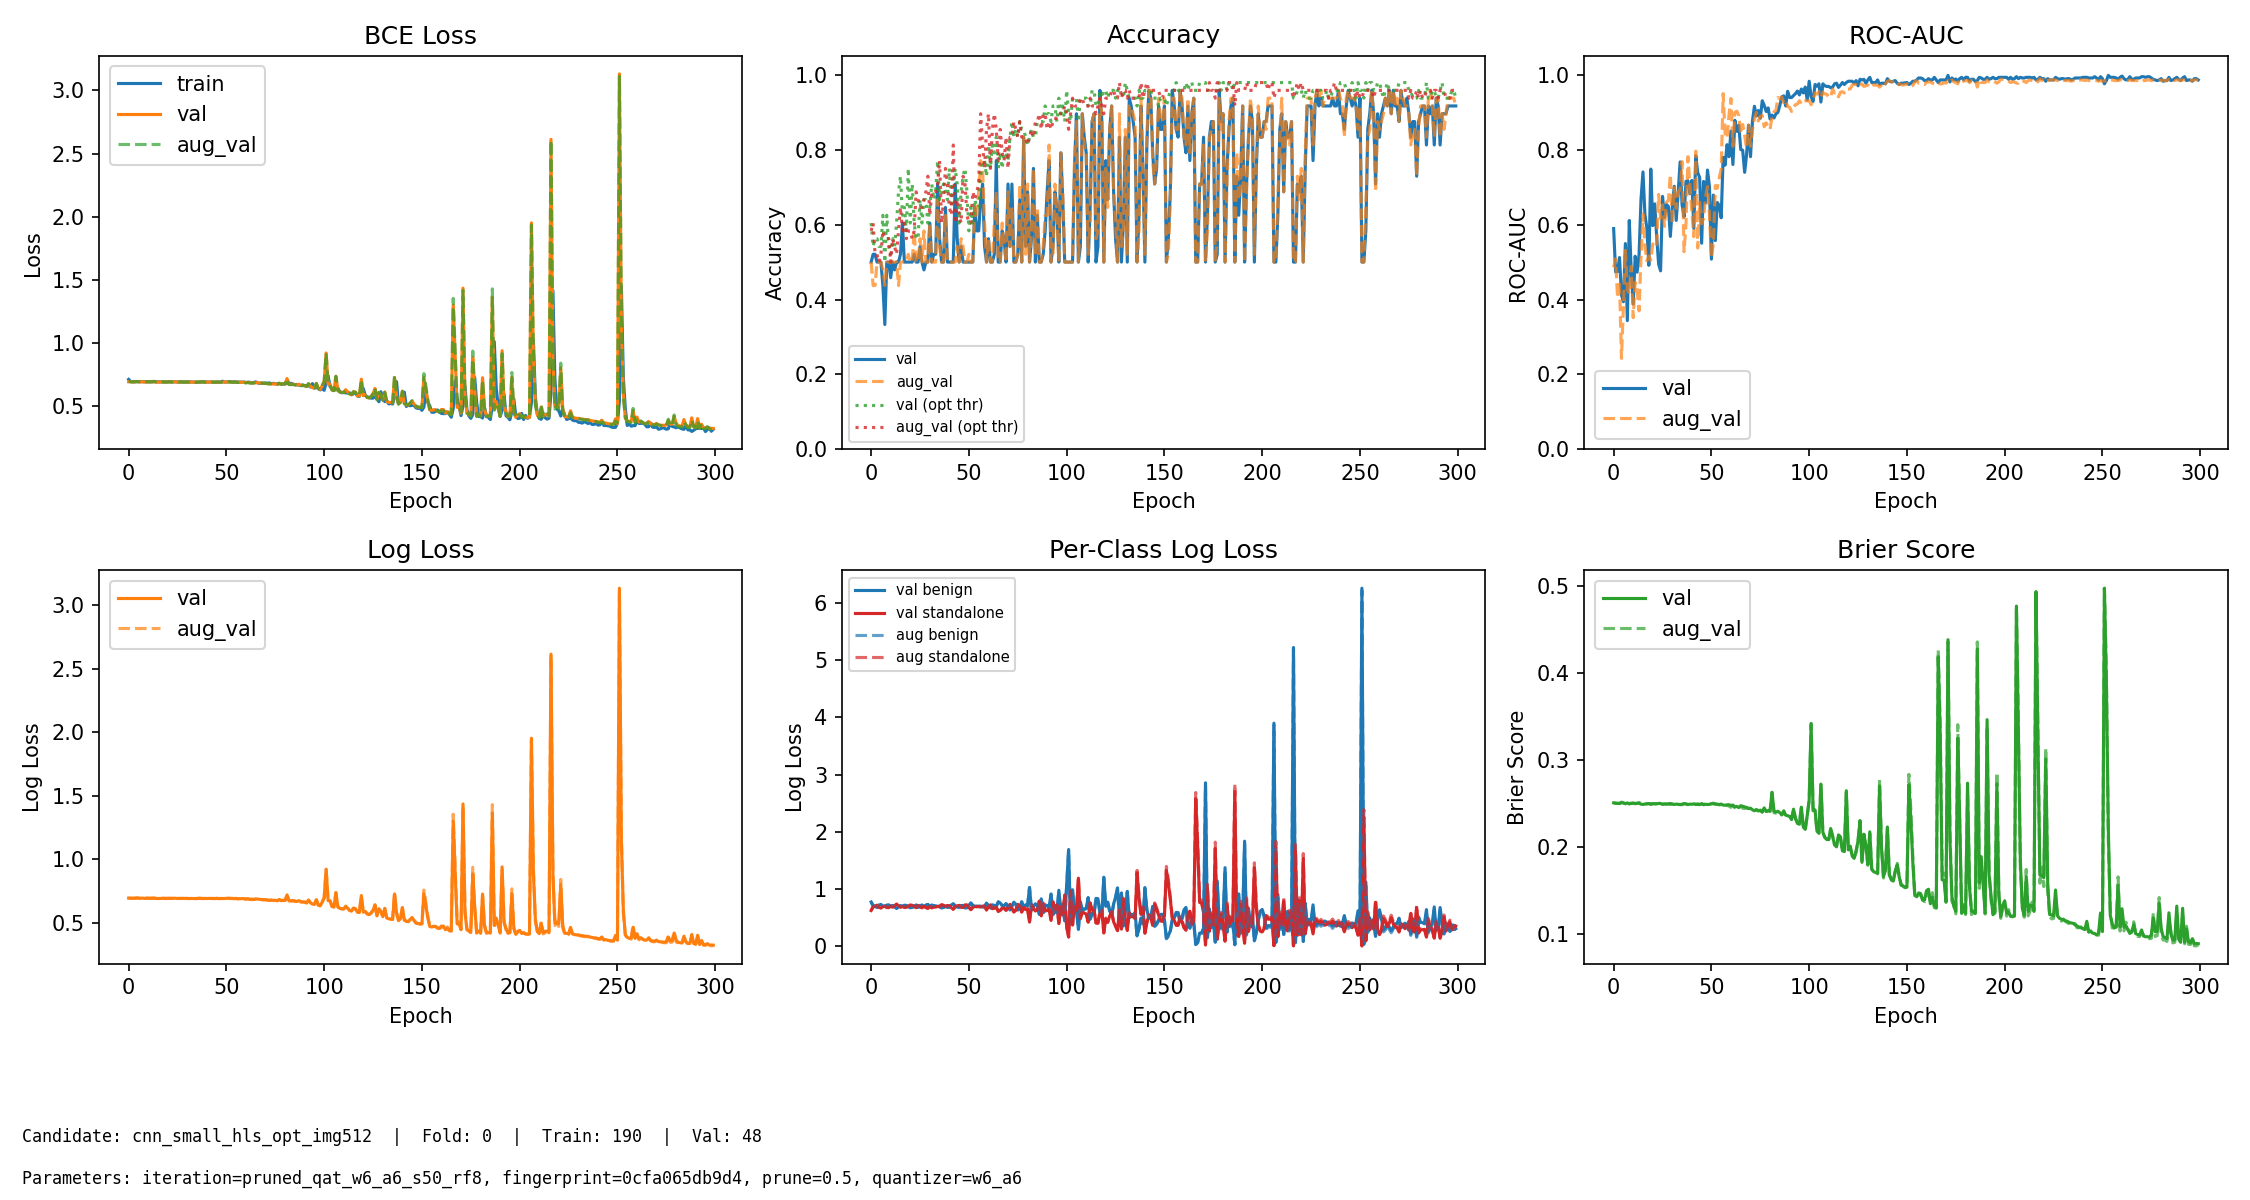

/pub/scratch/sdeheredia/Coyote/examples/ml_baseline/hls4ml/artifacts/cnn_small_hls_opt_img512/notebook_pruned_qat/pruned_qat_w6_a6_s50_rf8_0cfa065db9d4/fold_0/evaluation_dashboard.png


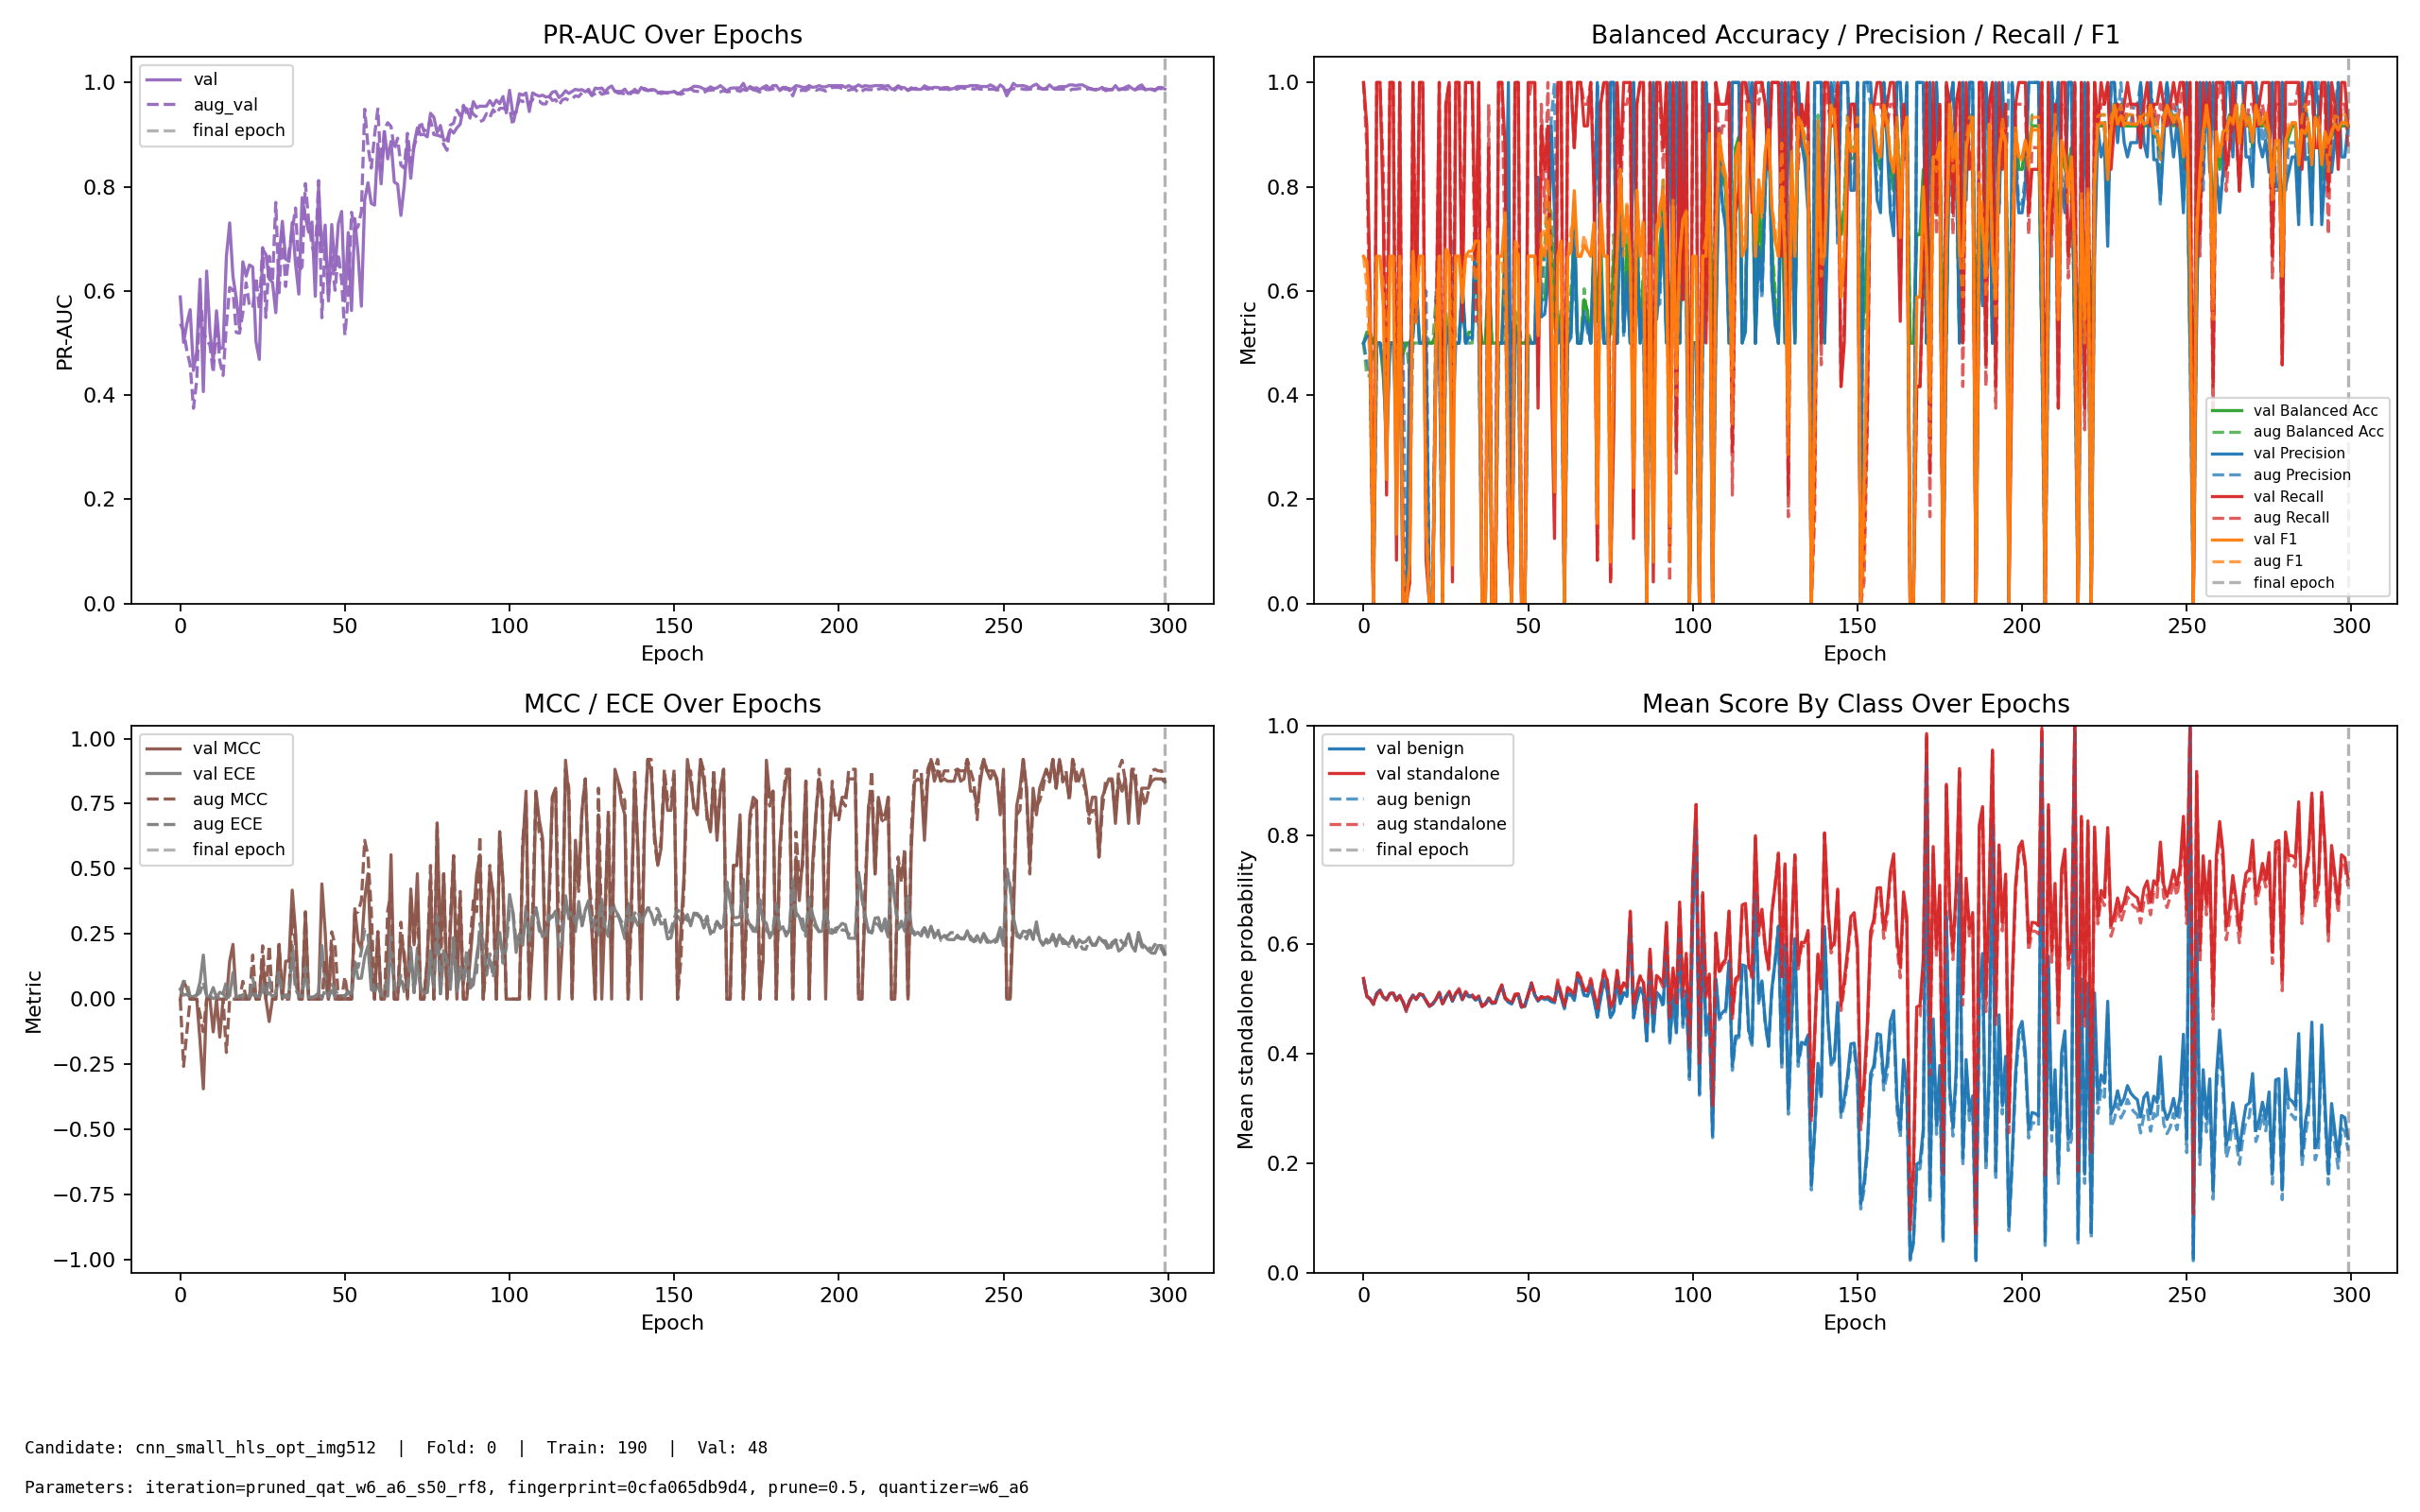

/pub/scratch/sdeheredia/Coyote/examples/ml_baseline/hls4ml/artifacts/cnn_small_hls_opt_img512/notebook_pruned_qat/pruned_qat_w6_a6_s50_rf8_0cfa065db9d4/fold_0/final_evaluation_plots.png


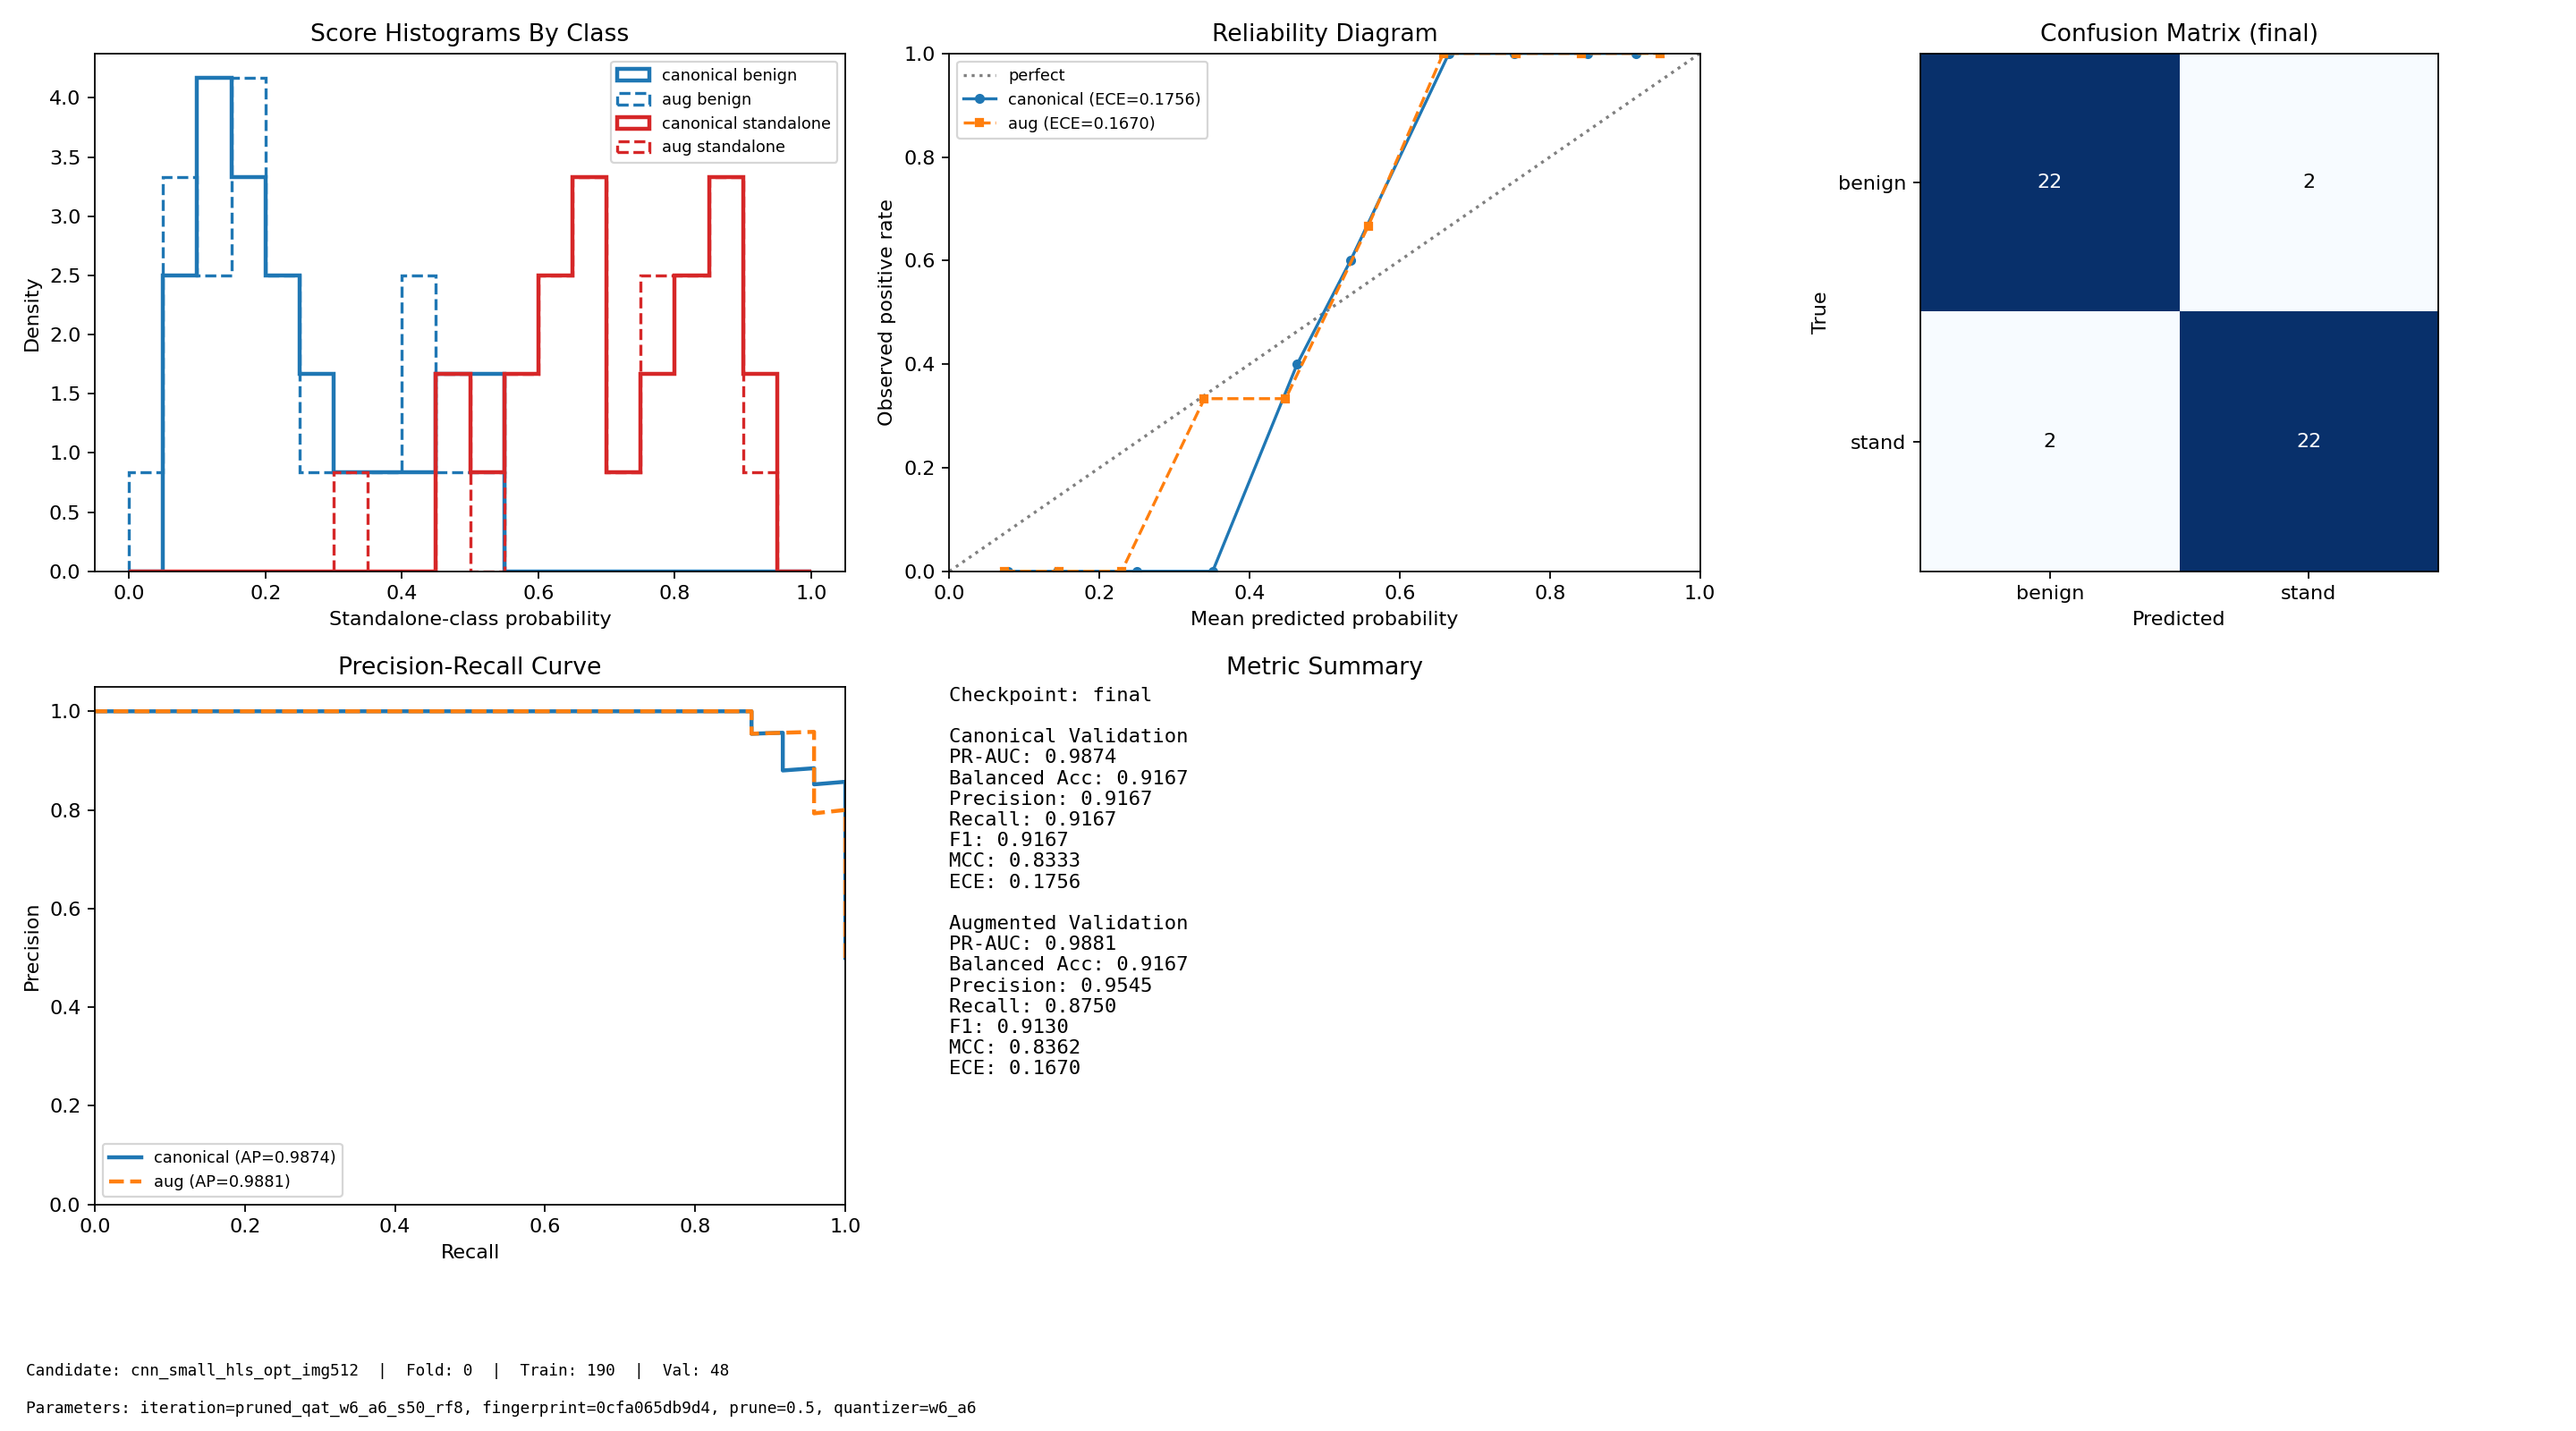

In [10]:
primary_result = train_or_load_fold(PRIMARY_FOLD)
trained_qkeras = primary_result["model"]

primary_metrics = primary_result["metrics"]
metric_keys = ["accuracy", "balanced_accuracy", "roc_auc", "pr_auc", "bce_loss", "optimal_accuracy", "optimal_threshold"]
display(pd.DataFrame([{key: primary_metrics.get(key) for key in metric_keys}], index=[f"fold_{PRIMARY_FOLD}"]))

for path in [
    fold_dir(PRIMARY_FOLD) / "training_curves.png",
    fold_dir(PRIMARY_FOLD) / "evaluation_dashboard.png",
    fold_dir(PRIMARY_FOLD) / "final_evaluation_plots.png",
]:
    if path.exists():
        print(path)
        display(Image(filename=str(path)))

## Check Sparsity

,layer,class,n_weights,n_nonzero_weights,zero_fraction,min,max,suggested_hls_strategy
0,conv0,QConv2D,200,100,0.5,-0.326214,0.399448,Latency
1,conv1,QConv2D,1152,576,0.5,-0.237854,0.293033,Latency
2,conv2,QConv2D,3456,1728,0.5,-0.255685,0.323828,Latency
3,conv3,QConv2D,5184,2592,0.5,-0.227562,0.260774,Latency
4,conv4,QConv2D,6912,3456,0.5,-0.254289,0.223820,Latency
5,output_dense,QDense,32,32,0.0,-0.340713,0.348298,Latency


,layer,n_weights,n_nonzero_weights,zero_fraction,suggested_hls_strategy
0,conv0,200,100,0.5,Latency
1,conv1,1152,576,0.5,Latency
2,conv2,3456,1728,0.5,Latency
3,conv3,5184,2592,0.5,Latency
4,conv4,6912,3456,0.5,Latency
5,output_dense,32,32,0.0,Latency


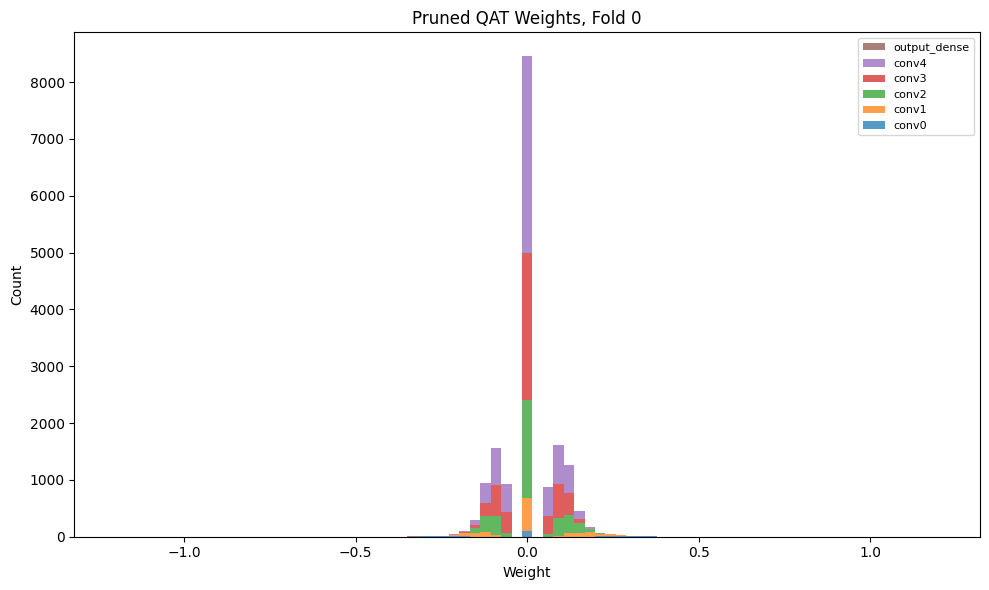

In [11]:
def weight_sparsity(model):
    rows = []
    weights_by_layer = []
    labels = []
    strategy_overrides = {}
    for layer in model.layers:
        ws = layer.get_weights()
        if not ws:
            continue
        w = np.asarray(ws[0]).reshape(-1)
        n_weights = int(w.size)
        n_nonzero_weights = int(np.count_nonzero(w))
        suggested_strategy = HLS_RESOURCE_STRATEGY if n_nonzero_weights > HLS_RESOURCE_STRATEGY_THRESHOLD else HLS_STRATEGY
        rows.append({
            "layer": layer.name,
            "class": layer.__class__.__name__,
            "n_weights": n_weights,
            "n_nonzero_weights": n_nonzero_weights,
            "zero_fraction": float(np.mean(w == 0.0)),
            "min": float(np.min(w)),
            "max": float(np.max(w)),
            "suggested_hls_strategy": suggested_strategy,
        })
        weights_by_layer.append(w)
        labels.append(layer.name)
        strategy_overrides[layer.name] = suggested_strategy
    return pd.DataFrame(rows), weights_by_layer, labels, strategy_overrides

sparsity_df, weights_by_layer, labels, hls_strategy_overrides = weight_sparsity(trained_qkeras)
display(sparsity_df)
display(sparsity_df[["layer", "n_weights", "n_nonzero_weights", "zero_fraction", "suggested_hls_strategy"]])

fig = plt.figure(figsize=(10, 6))
plt.hist(weights_by_layer, bins=np.linspace(-1.2, 1.2, 80), histtype="stepfilled", stacked=True, label=labels, alpha=0.75)
plt.legend(fontsize=8)
plt.xlabel("Weight")
plt.ylabel("Count")
plt.title(f"Pruned QAT Weights, Fold {PRIMARY_FOLD}")
fig.tight_layout()
display(fig)
plt.close(fig)

## hls4ml Compile, Spec, and Plot for Primary Fold

In [12]:
def qkeras_hls_config_for_model(model) -> dict:
    import hls4ml
    import keras

    keras_version = keras.__version__
    keras.__version__ = "2.15.0"
    try:
        config = hls4ml.utils.config_from_keras_model(model, granularity="name", backend=HLS_BACKEND)
    finally:
        keras.__version__ = keras_version

    config.setdefault("Model", {})
    config["Model"]["Strategy"] = HLS_STRATEGY
    config["Model"]["ReuseFactor"] = HLS_REUSE_FACTOR
    _, _, _, strategy_overrides = weight_sparsity(model)
    for layer_name, layer_cfg in config.get("LayerName", {}).items():
        layer_cfg["ReuseFactor"] = HLS_REUSE_FACTOR
        layer_cfg["Strategy"] = strategy_overrides.get(layer_name, HLS_STRATEGY)
        precision = layer_cfg.get("Precision")
        if HLS_ACCUM_PRECISION and isinstance(precision, dict) and "accum" in precision:
            precision["accum"] = HLS_ACCUM_PRECISION
    if "output_dense" in config.get("LayerName", {}):
        config["LayerName"]["output_dense"].setdefault("Precision", {})["result"] = HLS_OUTPUT_PRECISION
    if "gap" in config.get("LayerName", {}) and HLS_POOL_ACCUM_PRECISION is not None:
        config["LayerName"]["gap"].setdefault("Precision", {})["accum"] = HLS_POOL_ACCUM_PRECISION
    return config


def hls_fold_dir(fold: int) -> Path:
    return HLS_SWEEP_ROOT / f"fold_{fold}"


def hls_dir(fold: int) -> Path:
    return hls_fold_dir(fold) / "project"


def compile_hls_for_fold(fold: int, model):
    import hls4ml
    import keras

    out_dir = hls_dir(fold)
    out_dir.mkdir(parents=True, exist_ok=True)
    project_name = f"{CANDIDATE_NAME}_{ITERATION_NAME}_{HLS_SWEEP_LABEL}_fold{fold}_hls_{HLS_SHORT_FINGERPRINT[:8]}"
    manifest_path = out_dir / "conversion_manifest.json"
    if manifest_path.exists():
        manifest = json.loads(manifest_path.read_text())
        if manifest.get("hls_fingerprint") == HLS_FINGERPRINT and (out_dir / "hls4ml_config.yml").exists():
            print(f"Fold {fold}: hls4ml exact cache hit at {out_dir}")
    config = qkeras_hls_config_for_model(model)
    keras_version = keras.__version__
    keras.__version__ = "2.15.0"
    try:
        hls_model = hls4ml.converters.convert_from_keras_model(
            model,
            hls_config=config,
            output_dir=str(out_dir),
            project_name=project_name,
            backend=HLS_BACKEND,
            io_type=HLS_IO_TYPE,
            part=HLS_PART,
            clock_period=HLS_CLOCK_PERIOD,
        )
    finally:
        keras.__version__ = keras_version
    hls_model.compile()
    manifest_path.write_text(json.dumps({
        "training_fingerprint": TRAINING_FINGERPRINT,
        "hls_fingerprint": HLS_FINGERPRINT,
        "fold": fold,
        "project_name": project_name,
        "hls_config": HLS_CONFIG,
        "hls_dir": str(out_dir),
    }, indent=2, sort_keys=True))
    return hls_model, config, out_dir


hls_model_primary, hls_config_primary, hls_primary_dir = compile_hls_for_fold(PRIMARY_FOLD, trained_qkeras)
print("hls sweep root:", HLS_SWEEP_ROOT)
print("hls dir:", hls_primary_dir)
print("Model config:")
pprint.pp(hls_config_primary.get("Model", {}))

print("\nFull hls4ml configuration:")
try:
    from hls4ml.utils import plotting
    plotting.print_dict(hls_config_primary)
except Exception:
    pprint.pp(hls_config_primary)

print("\nCompiled hls4ml model summary:")
try:
    hls_model_primary.summary()
except Exception as exc:
    print("summary unavailable:", exc)

layer_rows = []
for name, layer_cfg in hls_config_primary.get("LayerName", {}).items():
    precision = layer_cfg.get("Precision", {})
    layer_rows.append({
        "layer": name,
        "strategy": layer_cfg.get("Strategy"),
        "reuse_factor": layer_cfg.get("ReuseFactor"),
        "result_precision": precision.get("result") if isinstance(precision, dict) else precision,
        "accum_precision": precision.get("accum") if isinstance(precision, dict) else None,
        "weight_precision": precision.get("weight") if isinstance(precision, dict) else None,
    })
display(pd.DataFrame(layer_rows))


/pub/scratch/sdeheredia/Coyote/examples/ml_baseline/.venv/lib/python3.10/site-packages/tf_keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


hls sweep root: /pub/scratch/sdeheredia/Coyote/examples/ml_baseline/hls4ml/artifacts/cnn_small_hls_opt_img512/notebook_pruned_qat/pruned_qat_w6_a6_s50_rf8_0cfa065db9d4/hls_sweeps/hls_b1649c98dace
hls dir: /pub/scratch/sdeheredia/Coyote/examples/ml_baseline/hls4ml/artifacts/cnn_small_hls_opt_img512/notebook_pruned_qat/pruned_qat_w6_a6_s50_rf8_0cfa065db9d4/hls_sweeps/hls_b1649c98dace/fold_0/project
Model config:
{'Precision': {'default': 'fixed<16,6>'},
 'ReuseFactor': 1,
 'Strategy': 'Latency',
 'BramFactor': 1000000000,
 'TraceOutput': False,
 'BitExact': None}

Full hls4ml configuration:
{'Model': {'Precision': {'default': 'fixed<16,6>'},
           'ReuseFactor': 1,
           'Strategy': 'Latency',
           'BramFactor': 1000000000,
           'TraceOutput': False,
           'BitExact': None},
 'LayerName': {'bitstream_input': {'Trace': False,
                                   'Precision': {'result': 'auto'},
                                   'ReuseFactor': 1,
                 

,layer,strategy,reuse_factor,result_precision,accum_precision,weight_precision
0,bitstream_input,Latency,1,auto,None,None
1,pad_conv0,Latency,1,auto,None,None
2,conv0,Latency,1,auto,auto,"fixed<6,1,TRN,WRAP,0>"
3,conv0_linear,Latency,1,auto,None,None
4,act0,Latency,1,"ufixed<6,2,RND_CONV,SAT,0>",None,None
5,pool0,Latency,1,auto,auto,None
6,pad_conv1,Latency,1,auto,None,None
7,conv1,Latency,1,auto,auto,"fixed<6,1,TRN,WRAP,0>"
8,conv1_linear,Latency,1,auto,None,None
9,act1,Latency,1,"ufixed<6,2,RND_CONV,SAT,0>",None,None


numerical profiling failed: 'Node' object has no attribute 'arguments'


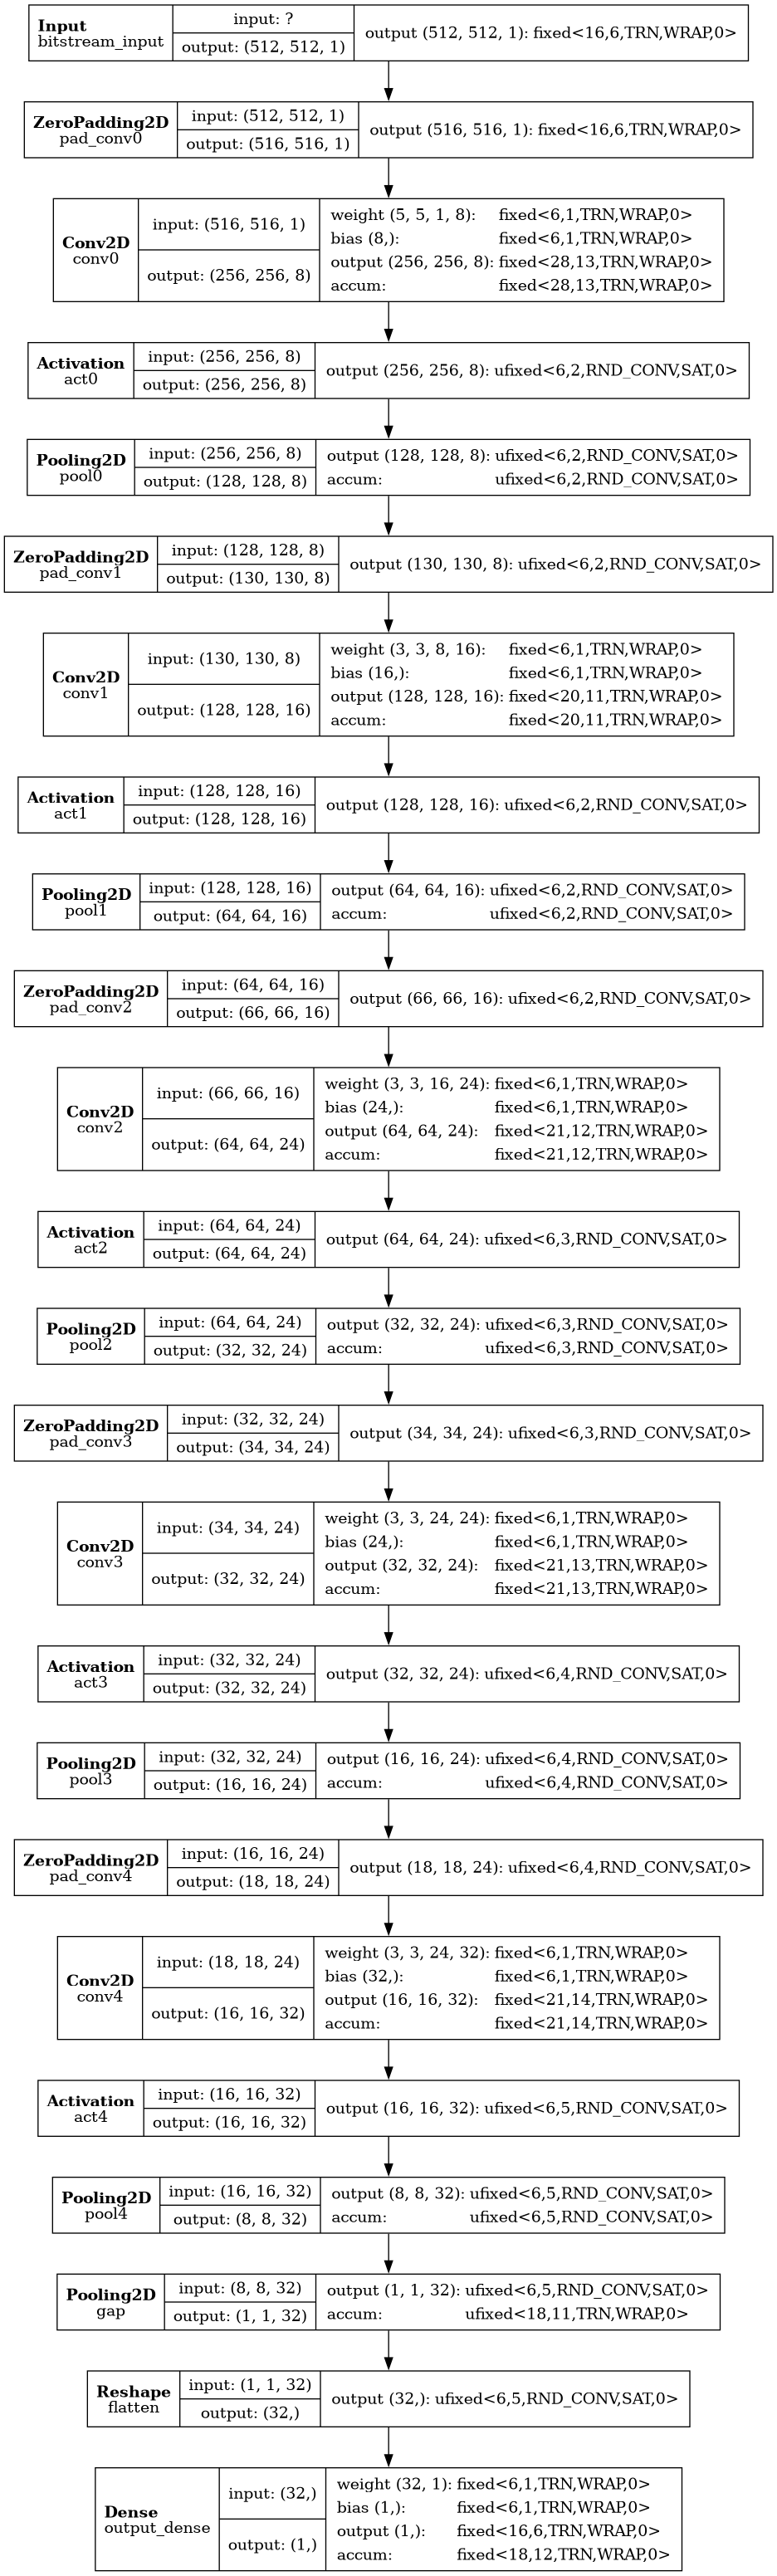

/pub/scratch/sdeheredia/Coyote/examples/ml_baseline/hls4ml/artifacts/cnn_small_hls_opt_img512/notebook_pruned_qat/pruned_qat_w6_a6_s50_rf8_0cfa065db9d4/hls_sweeps/hls_b1649c98dace/fold_0/project/hls4ml_model.png


In [13]:
import hls4ml
from hls4ml.model.profiling import numerical

try:
    numerical(model=trained_qkeras, hls_model=hls_model_primary)
except Exception as exc:
    print("numerical profiling failed:", exc)

plot_path = hls_primary_dir / "hls4ml_model.png"
try:
    hls4ml.utils.plot_model(
        hls_model_primary,
        show_shapes=True,
        show_precision=True,
        to_file=str(plot_path),
    )
    display(Image(filename=str(plot_path)))
    print(plot_path)
except Exception as exc:
    print("plot_model failed:", exc)
    print("pydot/dot check:")
    try:
        import pydot
        print("pydot", pydot.__version__, "dot", shutil.which("dot"))
        pydot.Dot().create(format="png")
    except Exception as pydot_exc:
        print("pydot smoke test failed:", pydot_exc)
    print("Inspect YAML instead:", hls_primary_dir / "hls4ml_config.yml")

## Bit-Accurate Emulation for Primary Fold

Saved checkpoint plots: /pub/scratch/sdeheredia/Coyote/examples/ml_baseline/hls4ml/artifacts/cnn_small_hls_opt_img512/notebook_pruned_qat/pruned_qat_w6_a6_s50_rf8_0cfa065db9d4/hls_sweeps/hls_b1649c98dace/fold_0/parity/qkeras_eval/final_evaluation_plots.png
Saved checkpoint plots: /pub/scratch/sdeheredia/Coyote/examples/ml_baseline/hls4ml/artifacts/cnn_small_hls_opt_img512/notebook_pruned_qat/pruned_qat_w6_a6_s50_rf8_0cfa065db9d4/hls_sweeps/hls_b1649c98dace/fold_0/parity/hls_eval/final_evaluation_plots.png


,training_fingerprint,hls_fingerprint,fold,n,logit_mae,logit_max_abs,sign_mismatches,qkeras_accuracy,hls_accuracy,qkeras_pr_auc,hls_pr_auc,qkeras_eval_plot,hls_eval_plot
0,0cfa065db9d45e24d1cfbb0417fe9c4b5384f6e503273f...,b1649c98dace9076b975486c2680b292dd1d6ca71d530f...,0,48,0.118678,0.387207,1,0.916667,0.9375,0.98924,0.990225,/pub/scratch/sdeheredia/Coyote/examples/ml_bas...,/pub/scratch/sdeheredia/Coyote/examples/ml_bas...


/pub/scratch/sdeheredia/Coyote/examples/ml_baseline/hls4ml/artifacts/cnn_small_hls_opt_img512/notebook_pruned_qat/pruned_qat_w6_a6_s50_rf8_0cfa065db9d4/hls_sweeps/hls_b1649c98dace/fold_0/parity/qkeras_eval/final_evaluation_plots.png


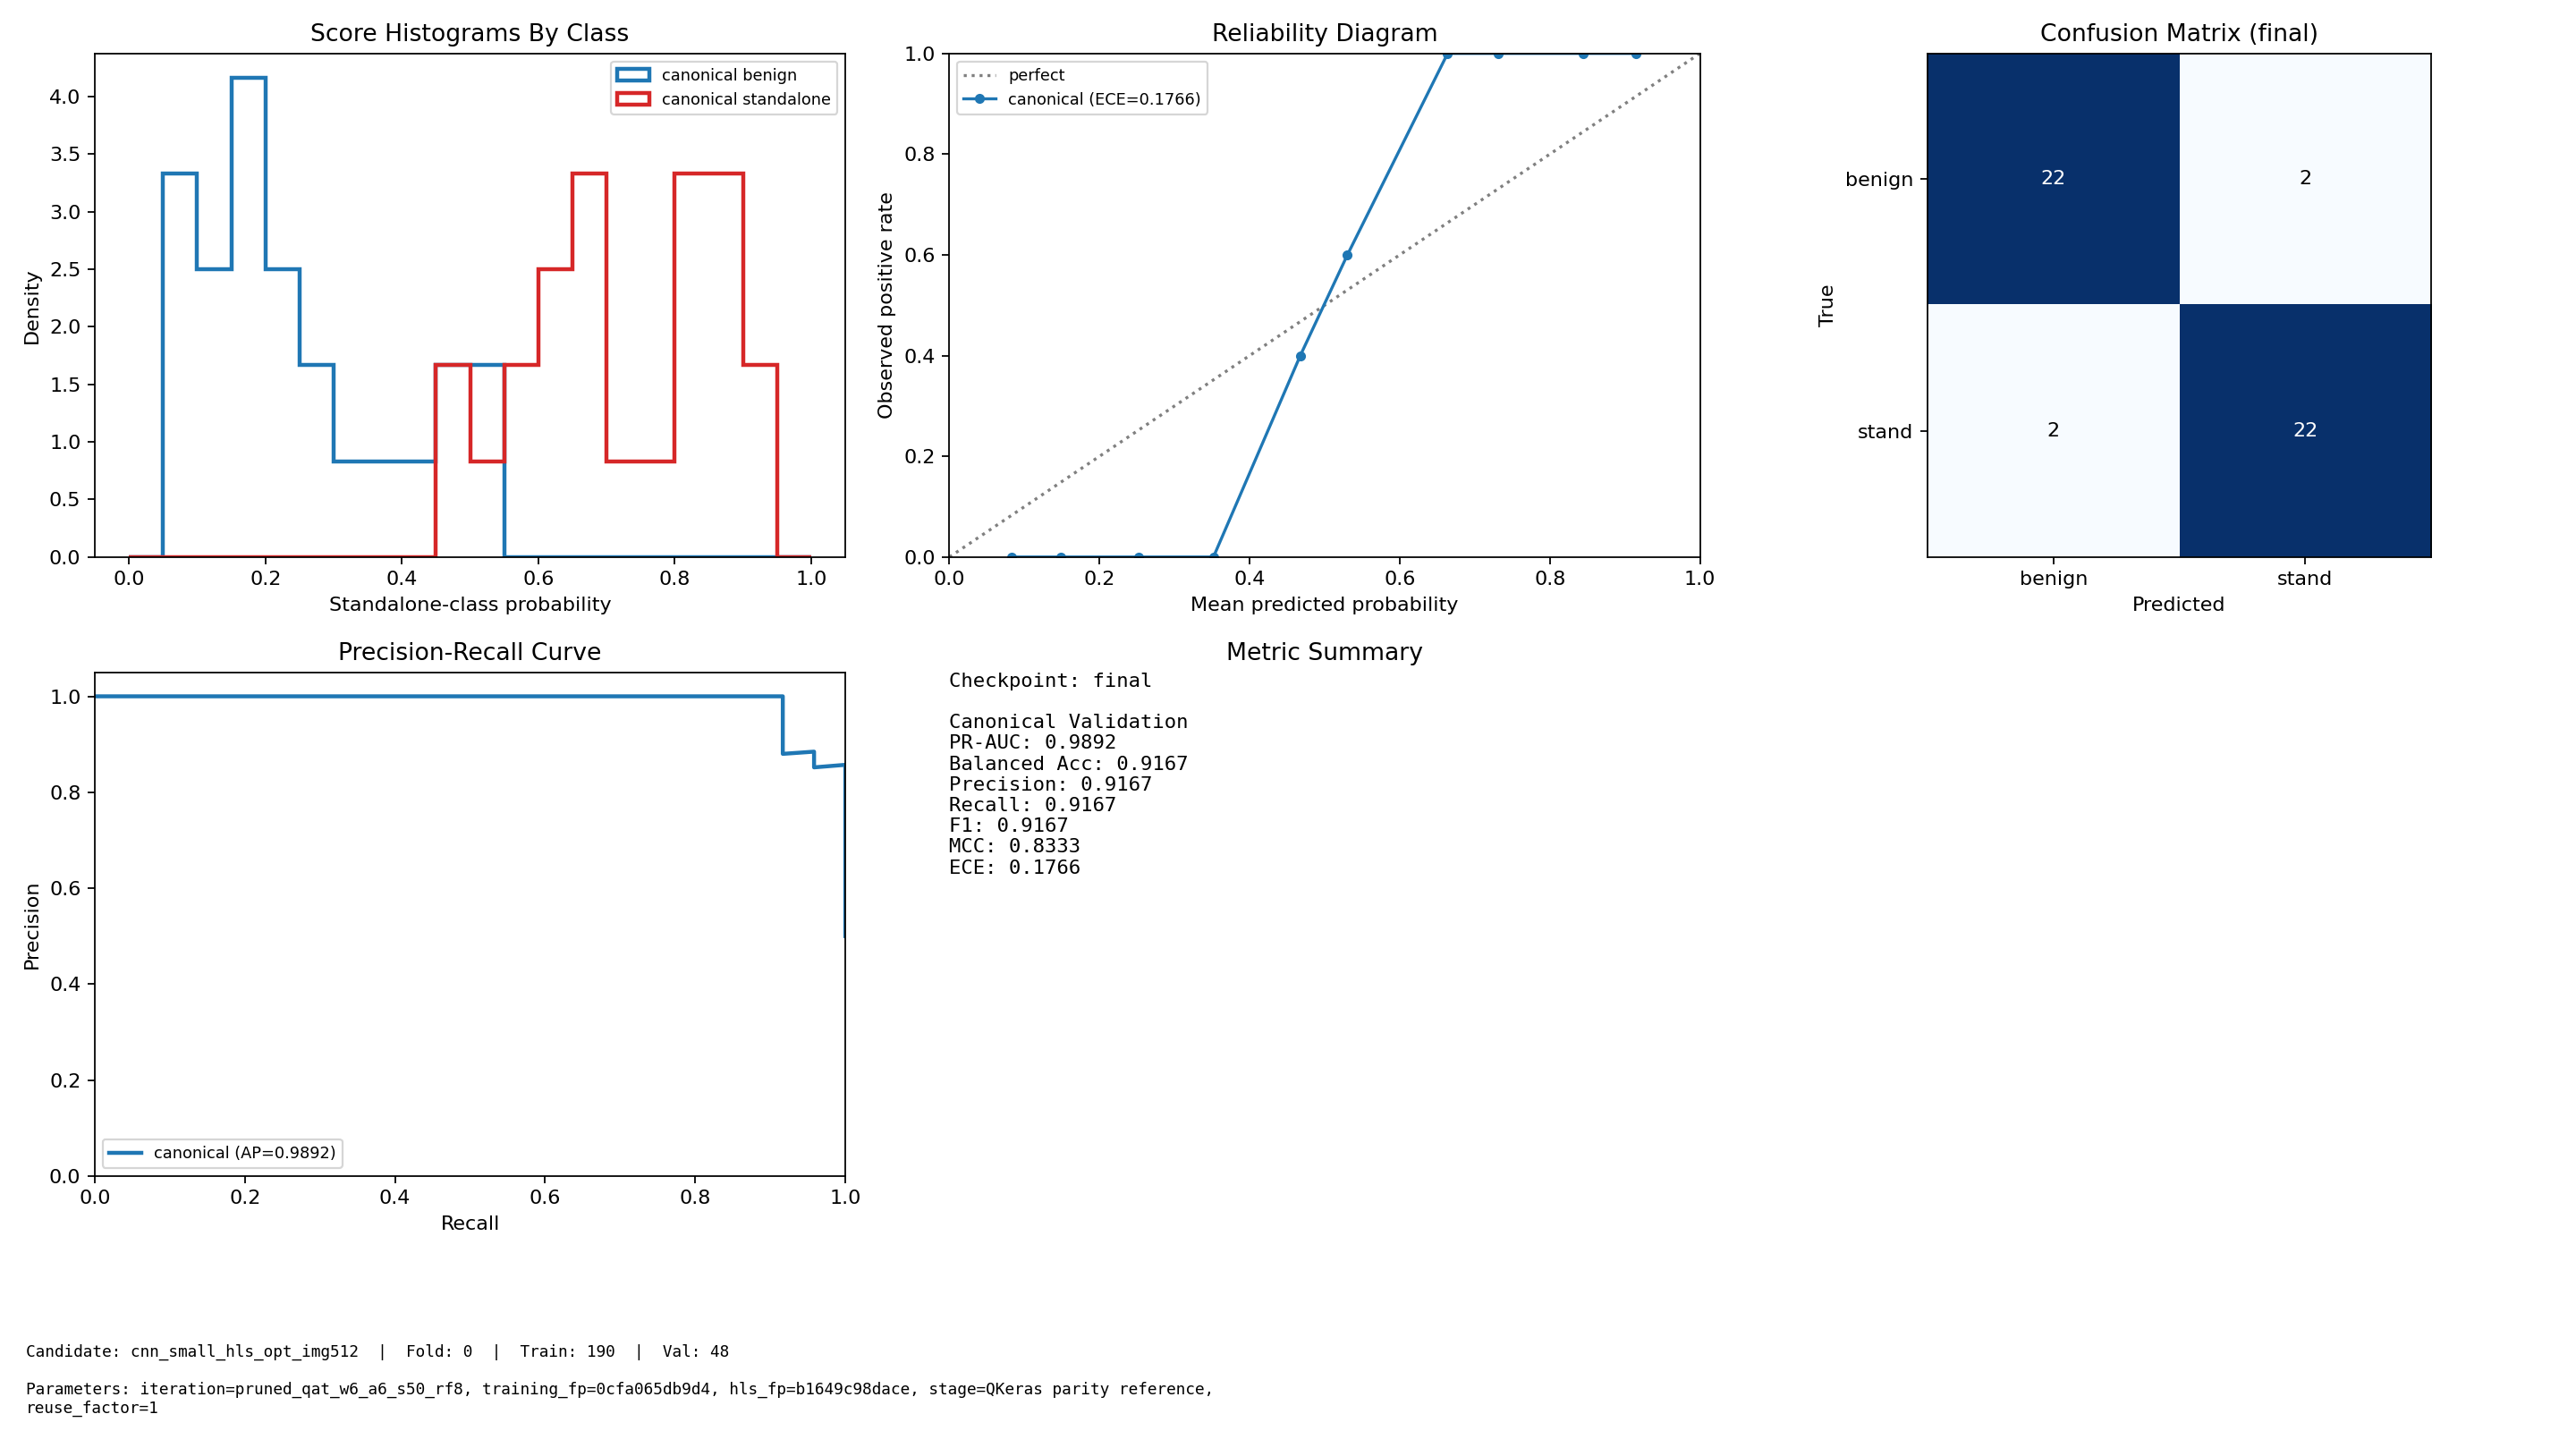

/pub/scratch/sdeheredia/Coyote/examples/ml_baseline/hls4ml/artifacts/cnn_small_hls_opt_img512/notebook_pruned_qat/pruned_qat_w6_a6_s50_rf8_0cfa065db9d4/hls_sweeps/hls_b1649c98dace/fold_0/parity/hls_eval/final_evaluation_plots.png


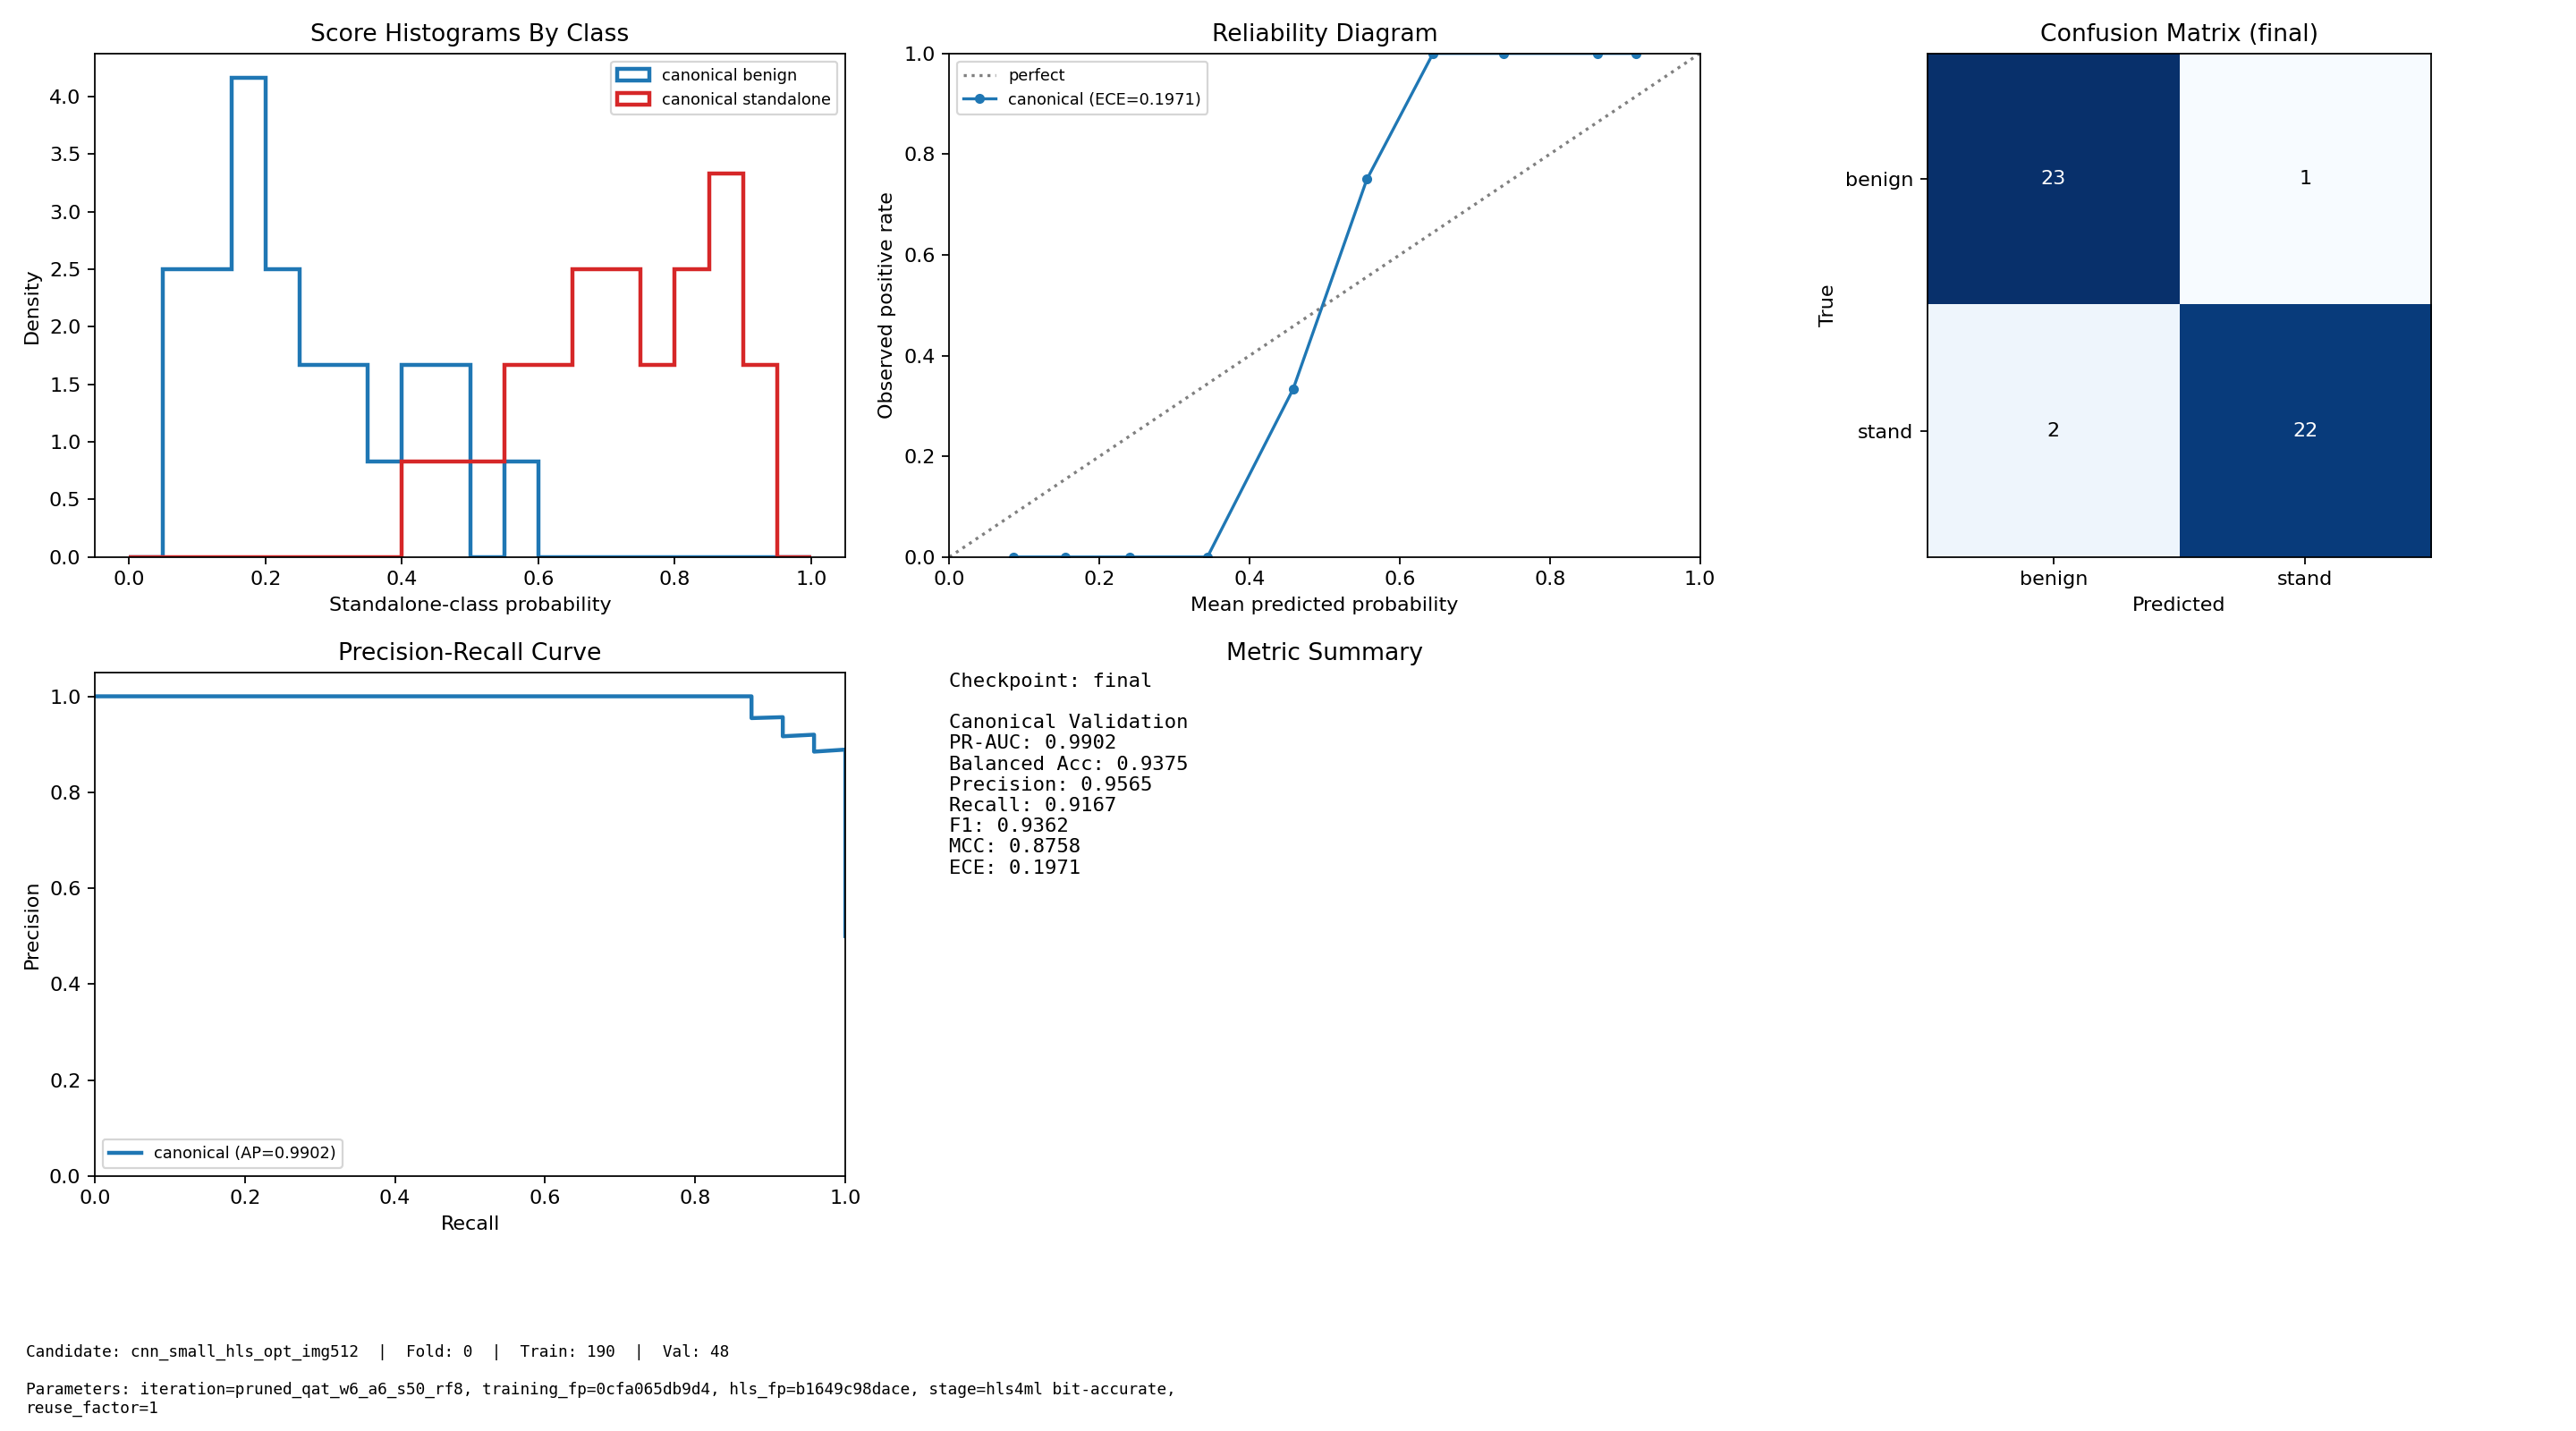

In [14]:
def sigmoid(logits):
    logits = np.asarray(logits, dtype=np.float64)
    out = np.empty_like(logits)
    pos = logits >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-logits[pos]))
    exp_x = np.exp(logits[~pos])
    out[~pos] = exp_x / (1.0 + exp_x)
    return out


def validation_arrays_for_fold(fold: int):
    _, val_samples = splits[fold]
    xs = [sample_to_nhwc(sample, candidate) for sample in val_samples]
    ys = np.asarray([int(sample["class_label"]) for sample in val_samples], dtype=np.int32)
    x = np.stack(xs).astype(np.float32)
    if N_EMULATION_SAMPLES is not None:
        x = x[:N_EMULATION_SAMPLES]
        ys = ys[:N_EMULATION_SAMPLES]
        val_samples = val_samples[:N_EMULATION_SAMPLES]
    return x, ys, val_samples


def parity_dir_for_fold(fold: int) -> Path:
    return hls_fold_dir(fold) / "parity"


def binary_log_loss(label: int, prob: float) -> float:
    p = min(max(float(prob), 1e-7), 1.0 - 1e-7)
    return -math.log(p) if int(label) == 1 else -math.log(1.0 - p)


def rows_from_logits(samples, labels, logits):
    probs = sigmoid(np.asarray(logits).reshape(-1))
    rows = []
    for idx, (sample, label, logit, prob) in enumerate(zip(samples, labels, logits, probs)):
        pred = int(prob >= 0.5)
        loss = binary_log_loss(int(label), float(prob))
        rows.append({
            "sample_index": idx,
            "sample_id": sample.get("sample_id", ""),
            "app_name": sample.get("app_name", ""),
            "class_label": int(label),
            "class_name": sample.get("class_name", "standalone" if int(label) else "benign"),
            "ro_count": sample.get("ro_count", ""),
            "bitstream_path": sample.get("bitstream_path", ""),
            "logit": f"{float(logit):.9f}",
            "probability": f"{float(prob):.9f}",
            "predicted_label": pred,
            "correct": pred == int(label),
            "per_sample_bce_loss": f"{loss:.9f}",
            "per_sample_log_loss": f"{loss:.9f}",
        })
    return rows


def metrics_from_stage_rows(rows):
    labels = np.asarray([int(row["class_label"]) for row in rows], dtype=np.float32)
    probs = np.asarray([float(row["probability"]) for row in rows], dtype=np.float32)
    losses = np.asarray([float(row["per_sample_bce_loss"]) for row in rows], dtype=np.float32)
    return compute_metrics_from_outputs(float(np.mean(losses)), labels, probs)


def write_csv(path: Path, rows: list[dict]):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)


def save_stage_eval_artifacts(fold: int, parity_dir: Path, stage_name: str, metrics: dict, stage_label: str):
    train_samples, _ = splits[fold]
    stage_dir = parity_dir / f"{stage_name}_eval"
    stage_dir.mkdir(parents=True, exist_ok=True)
    write_metrics_summary(
        stage_dir / "metrics_summary.json",
        metrics,
        extra={
            "training_fingerprint": TRAINING_FINGERPRINT,
            "hls_fingerprint": HLS_FINGERPRINT,
            "fold": fold,
            "stage": stage_name,
            "candidate": CANDIDATE_NAME,
        },
    )
    split_info = build_split_info(CANDIDATE_NAME, fold, len(train_samples), len(metrics["labels"]))
    save_checkpoint_plots(
        str(stage_dir),
        "final",
        metrics,
        aug_metrics=None,
        split_info=split_info,
        run_params={
            "iteration": ITERATION_NAME,
            "training_fp": TRAINING_SHORT_FINGERPRINT,
            "hls_fp": HLS_SHORT_FINGERPRINT,
            "stage": stage_label,
            "reuse_factor": HLS_REUSE_FACTOR,
        },
    )
    return stage_dir / "final_evaluation_plots.png"


def emulate_fold(fold: int, model, hls_model):
    parity_dir = parity_dir_for_fold(fold)
    parity_dir.mkdir(parents=True, exist_ok=True)
    x, labels, val_samples = validation_arrays_for_fold(fold)
    keras_logits = np.asarray(model.predict(x, verbose=0)).reshape(-1)
    hls_logits = np.asarray(hls_model.predict(np.ascontiguousarray(x))).reshape(-1)
    abs_err = np.abs(hls_logits - keras_logits)
    parity_rows = []
    for idx, (label, k_logit, h_logit, err) in enumerate(zip(labels, keras_logits, hls_logits, abs_err)):
        parity_rows.append({
            "idx": idx,
            "label": int(label),
            "keras_logit": float(k_logit),
            "hls_logit": float(h_logit),
            "abs_err": float(err),
            "rel_err": float(err / max(abs(float(k_logit)), 1e-6)),
        })
    write_csv(parity_dir / "parity.csv", parity_rows)

    keras_rows = rows_from_logits(val_samples, labels, keras_logits)
    hls_rows = rows_from_logits(val_samples, labels, hls_logits)
    write_csv(parity_dir / "qkeras_per_sample.csv", keras_rows)
    write_csv(parity_dir / "hls_per_sample.csv", hls_rows)

    keras_metrics = metrics_from_stage_rows(keras_rows)
    hls_metrics = metrics_from_stage_rows(hls_rows)
    qkeras_plot = save_stage_eval_artifacts(fold, parity_dir, "qkeras", keras_metrics, "QKeras parity reference")
    hls_plot = save_stage_eval_artifacts(fold, parity_dir, "hls", hls_metrics, "hls4ml bit-accurate")
    summary = {
        "training_fingerprint": TRAINING_FINGERPRINT,
        "hls_fingerprint": HLS_FINGERPRINT,
        "fold": fold,
        "n": int(len(labels)),
        "logit_mae": float(abs_err.mean()),
        "logit_max_abs": float(abs_err.max()),
        "sign_mismatches": int(np.sum((keras_logits >= 0.0) != (hls_logits >= 0.0))),
        "qkeras_accuracy": float(keras_metrics["accuracy"]),
        "hls_accuracy": float(hls_metrics["accuracy"]),
        "qkeras_pr_auc": float(keras_metrics["pr_auc"]),
        "hls_pr_auc": float(hls_metrics["pr_auc"]),
        "qkeras_eval_plot": str(qkeras_plot),
        "hls_eval_plot": str(hls_plot),
    }
    (parity_dir / "summary.json").write_text(json.dumps(summary, indent=2, sort_keys=True))
    return summary, keras_rows, hls_rows


primary_parity_summary, primary_qkeras_rows, primary_hls_rows = emulate_fold(PRIMARY_FOLD, trained_qkeras, hls_model_primary)
display(pd.DataFrame([primary_parity_summary]))
for key in ["qkeras_eval_plot", "hls_eval_plot"]:
    plot_path = Path(primary_parity_summary[key])
    if plot_path.exists():
        print(plot_path)
        display(Image(filename=str(plot_path)))


## Layer-Wise Divergence Trace for Primary Fold

In [ ]:
def layer_trace_dir(fold: int) -> Path:
    tag = "all" if N_LAYER_TRACE_SAMPLES is None else f"n{N_LAYER_TRACE_SAMPLES}"
    return parity_dir_for_fold(fold) / f"layer_trace_{tag}"


def layer_precision_rows(config: dict) -> dict[str, dict]:
    rows = {}
    for name, layer_cfg in config.get("LayerName", {}).items():
        precision = layer_cfg.get("Precision", {})
        rows[name] = {
            "reuse_factor": layer_cfg.get("ReuseFactor"),
            "result_precision": precision.get("result") if isinstance(precision, dict) else precision,
            "accum_precision": precision.get("accum") if isinstance(precision, dict) else None,
            "weight_precision": precision.get("weight") if isinstance(precision, dict) else None,
        }
    return rows


def summarize_layer_divergence(k_trace, h_trace, precision_map):
    rows = []
    for layer_name, hls_out in h_trace.items():
        if layer_name not in k_trace:
            continue
        keras_out = np.asarray(k_trace[layer_name], dtype=np.float64)
        hls_out = np.asarray(hls_out, dtype=np.float64)
        if keras_out.shape != hls_out.shape:
            print(f"Skipping {layer_name}: shape mismatch {keras_out.shape} vs {hls_out.shape}")
            continue
        diff = hls_out - keras_out
        flat_diff = diff.reshape(diff.shape[0], -1)
        flat_keras = keras_out.reshape(keras_out.shape[0], -1)
        abs_diff = np.abs(flat_diff)
        rmse_per_sample = np.sqrt(np.mean(np.square(flat_diff), axis=1))
        keras_rms = np.sqrt(np.mean(np.square(flat_keras), axis=1))
        precision = precision_map.get(layer_name, {})
        rows.append({
            "layer": layer_name,
            "shape": str(tuple(keras_out.shape[1:])),
            "n_values_per_sample": int(np.prod(keras_out.shape[1:])),
            "mean_abs_qkeras": float(np.mean(np.abs(flat_keras))),
            "mae": float(np.mean(abs_diff)),
            "rmse": float(np.mean(rmse_per_sample)),
            "max_abs": float(np.max(abs_diff)),
            "rel_rmse": float(np.mean(rmse_per_sample / np.maximum(keras_rms, 1e-12))),
            "cosine_similarity": float(
                np.mean(
                    np.sum(flat_keras * hls_out.reshape(hls_out.shape[0], -1), axis=1)
                    / (
                        np.linalg.norm(flat_keras, axis=1)
                        * np.linalg.norm(hls_out.reshape(hls_out.shape[0], -1), axis=1)
                        + 1e-12
                    )
                )
            ),
            "reuse_factor": precision.get("reuse_factor"),
            "result_precision": precision.get("result_precision"),
            "accum_precision": precision.get("accum_precision"),
            "weight_precision": precision.get("weight_precision"),
        })
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(["rmse", "max_abs"], ascending=False).reset_index(drop=True)


def compute_layer_trace_divergence(fold: int, model, hls_model, hls_config: dict):
    trace_dir = layer_trace_dir(fold)
    trace_dir.mkdir(parents=True, exist_ok=True)
    manifest_path = trace_dir / "trace_manifest.json"
    summary_path = trace_dir / "layer_divergence_summary.csv"

    x_trace, _, trace_samples = validation_arrays_for_fold(fold)
    if N_LAYER_TRACE_SAMPLES is not None:
        x_trace = x_trace[:N_LAYER_TRACE_SAMPLES]
        trace_samples = trace_samples[:N_LAYER_TRACE_SAMPLES]
    x_trace = np.ascontiguousarray(x_trace)

    if manifest_path.exists() and summary_path.exists():
        manifest = json.loads(manifest_path.read_text())
        if (
            manifest.get("hls_fingerprint") == HLS_FINGERPRINT
            and manifest.get("fold") == fold
            and manifest.get("n_trace_samples") == int(len(x_trace))
        ):
            print(f"Fold {fold}: layer-trace exact cache hit at {trace_dir}")
            return pd.read_csv(summary_path), trace_dir

    for layer in hls_model.get_layers():
        if layer.get_attr("function_cpp", None):
            layer.set_attr("trace", True)

    _, hls_trace = hls_model.trace(x_trace)
    trace_names = [name for name in hls_trace.keys() if name in {layer.name for layer in model.layers}]
    keras_trace_model = tf.keras.Model(
        inputs=model.input,
        outputs=[model.get_layer(name).output for name in trace_names],
    )
    keras_outputs = keras_trace_model.predict(x_trace, verbose=0)
    if not isinstance(keras_outputs, list):
        keras_outputs = [keras_outputs]
    keras_trace = {name: output for name, output in zip(trace_names, keras_outputs)}

    divergence_df = summarize_layer_divergence(
        keras_trace,
        hls_trace,
        layer_precision_rows(hls_config),
    )
    divergence_df.to_csv(summary_path, index=False)
    manifest_path.write_text(json.dumps({
        "training_fingerprint": TRAINING_FINGERPRINT,
        "hls_fingerprint": HLS_FINGERPRINT,
        "fold": fold,
        "n_trace_samples": int(len(x_trace)),
        "sample_ids": [sample.get("sample_id", "") for sample in trace_samples],
    }, indent=2, sort_keys=True))
    return divergence_df, trace_dir


layer_divergence_df, layer_trace_out_dir = compute_layer_trace_divergence(
    PRIMARY_FOLD,
    trained_qkeras,
    hls_model_primary,
    hls_config_primary,
)

display(layer_divergence_df)

if not layer_divergence_df.empty:
    top_rmse = layer_divergence_df.nlargest(min(12, len(layer_divergence_df)), "rmse").sort_values("rmse")
    top_max = layer_divergence_df.nlargest(min(12, len(layer_divergence_df)), "max_abs").sort_values("max_abs")
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].barh(top_rmse["layer"], top_rmse["rmse"])
    axes[0].set_title("Top Layer RMSE")
    axes[0].set_xlabel("RMSE")
    axes[1].barh(top_max["layer"], top_max["max_abs"])
    axes[1].set_title("Top Layer Max Abs Error")
    axes[1].set_xlabel("Max |HLS - QKeras|")
    fig.suptitle(f"Primary-Fold Layer Divergence (n={len(layer_divergence_df)} traced layers)")
    fig.tight_layout()
    plot_path = layer_trace_out_dir / "layer_divergence.png"
    fig.savefig(plot_path, dpi=160)
    display(fig)
    plt.close(fig)
    print(plot_path)


Recompiling cnn_small_hls_opt_img512_pruned_qat_w6_a6_s50_rf8_fold0_hls_b1649c98 with tracing


/pub/scratch/sdeheredia/Coyote/examples/ml_baseline/.venv/lib/python3.10/site-packages/tf_keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


## Representative Logic Synthesis

In [17]:
def find_csynth_report(project_dir: Path):
    candidates = sorted(Path(project_dir).glob("*_prj/solution1/syn/report/*_csynth.rpt"))
    top = [p for p in candidates if "_hls_csynth" in p.name or p.name == "csynth.rpt"]
    return (top or candidates or [None])[0]


def parse_csynth_report(report_path: Path | None):
    if report_path is None or not Path(report_path).exists():
        return {}
    text = Path(report_path).read_text(errors="ignore").splitlines()
    out = {"report": str(report_path)}
    for i, line in enumerate(text):
        if "Latency (cycles)" in line:
            for row in text[i + 1 : i + 10]:
                parts = [p.strip() for p in row.split("|")]
                nums = [p for p in parts if p.replace("-", "").replace(".", "").isdigit()]
                if len(nums) >= 2:
                    out["latency_min_cycles"] = int(float(nums[0]))
                    out["latency_max_cycles"] = int(float(nums[1]))
                    break
        if "Interval (cycles)" in line:
            for row in text[i + 1 : i + 10]:
                parts = [p.strip() for p in row.split("|")]
                nums = [p for p in parts if p.replace("-", "").replace(".", "").isdigit()]
                if nums:
                    out["interval_cycles"] = int(float(nums[0]))
                    break
    return out


def synthesize_fold_if_needed(fold: int):
    project_dir = hls_dir(fold)
    synth_manifest = project_dir / "synthesis_manifest.json"
    report = find_csynth_report(project_dir)
    if synth_manifest.exists() and report is not None:
        manifest = json.loads(synth_manifest.read_text())
        if manifest.get("hls_fingerprint") == HLS_FINGERPRINT:
            print(f"Fold {fold}: synthesis exact cache hit")
            row = {"fold": fold, "project_dir": str(project_dir), "cached": True}
            row.update(parse_csynth_report(report))
            return row

    if shutil.which("vitis_hls") is None:
        raise RuntimeError("vitis_hls is not on PATH. Run `source /opt/hdev/cli/enable/vitis` in the Jupyter server environment and restart the kernel/server.")
    if not (project_dir / "build_prj.tcl").exists():
        raise FileNotFoundError(f"Missing build_prj.tcl in {project_dir}")

    subprocess.run(["vitis_hls", "-f", "build_prj.tcl"], cwd=project_dir, check=True)
    report = find_csynth_report(project_dir)
    synth_manifest.write_text(json.dumps({
        "training_fingerprint": TRAINING_FINGERPRINT,
        "hls_fingerprint": HLS_FINGERPRINT,
        "fold": fold,
        "completed_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    }, indent=2, sort_keys=True))
    row = {"fold": fold, "project_dir": str(project_dir), "cached": False}
    row.update(parse_csynth_report(report))
    return row

synthesis_rows = [synthesize_fold_if_needed(fold) for fold in SYNTHESIS_FOLDS]
display(pd.DataFrame(synthesis_rows))



****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2024.2 (64-bit)
  **** SW Build 5238294 on Nov  8 2024
  **** IP Build 5239520 on Sun Nov 10 16:12:51 MST 2024
  **** SharedData Build 5239561 on Fri Nov 08 14:39:27 MST 2024
  **** Start of session at: Sun Apr 26 23:02:42 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

source /tools/Xilinx/Vitis/2024.2/scripts/vitis_hls/hls.tcl -notrace
INFO: [HLS 200-10] For user 'sdeheredia' on host 'hacc-build-02.inf.ethz.ch' (Linux_x86_64 version 6.8.0-107-generic) on Sun Apr 26 23:02:43 CEST 2026
INFO: [HLS 200-10] On os Ubuntu 22.04.5 LTS
INFO: [HLS 200-10] In directory '/pub/scratch/sdeheredia/Coyote/examples/ml_baseline/hls4ml/artifacts/cnn_small_hls_opt_img512/notebook_pruned_qat/pruned_qat_w6_a6_s50_rf8_0cfa065db9d4/hls_sweeps/hls_b1649c98dace/fold_0/project'
Sourcing Tcl script 'build_prj.tcl'
INFO: [HLS 200-1510] Running: open_proj

KeyboardInterrupt: 

## Train Remaining Folds and Produce Pooled K-Fold Plots

In [ ]:
fold_results = {PRIMARY_FOLD: primary_result}
for fold in range(K_FOLDS):
    if fold == PRIMARY_FOLD:
        continue
    fold_results[fold] = train_or_load_fold(fold)

ordered_fold_results = [fold_results[fold] for fold in range(K_FOLDS)]
plot_payload = []
for result in ordered_fold_results:
    plot_payload.append({
        "fold_label": f"fold_{result['fold']}",
        "history": result["history_columns"],
        "final_metrics": result["metrics"],
        "final_aug_metrics": result.get("aug_metrics"),
        "final_epoch": result["final_epoch"],
    })

write_kfold_plots(
    ITERATION_ROOT,
    plot_payload,
    split_info=f"Candidate: {CANDIDATE_NAME} | Iteration: {ITERATION_NAME} | Fingerprint: {SHORT_FINGERPRINT}",
    run_params={"quantizer": QUANTIZER_TAG, "prune": PRUNE_FINAL_SPARSITY, "epochs": EPOCHS, "batch_size": BATCH_SIZE, "lr": LR},
)

for path in [
    ITERATION_ROOT / "kfold_training_curves.png",
    ITERATION_ROOT / "evaluation_dashboard.png",
    ITERATION_ROOT / "final_evaluation_plots.png",
]:
    if path.exists():
        print(path)
        display(Image(filename=str(path)))

## Convert and Emulate All Folds, Then Compare Pooled Accuracy

In [ ]:
all_qkeras_rows = []
all_hls_rows = []
parity_summaries = []

for fold in range(K_FOLDS):
    model = fold_results[fold]["model"]
    hls_model, _, _ = compile_hls_for_fold(fold, model)
    summary, q_rows, h_rows = emulate_fold(fold, model, hls_model)
    parity_summaries.append(summary)
    for row in q_rows:
        row = dict(row)
        row["fold"] = fold
        all_qkeras_rows.append(row)
    for row in h_rows:
        row = dict(row)
        row["fold"] = fold
        all_hls_rows.append(row)

pooled_dir = HLS_SWEEP_ROOT / "pooled_parity"
pooled_dir.mkdir(parents=True, exist_ok=True)
write_csv(pooled_dir / "qkeras_per_sample.csv", all_qkeras_rows)
write_csv(pooled_dir / "hls_per_sample.csv", all_hls_rows)

qkeras_pooled_metrics = metrics_from_stage_rows(all_qkeras_rows)
hls_pooled_metrics = metrics_from_stage_rows(all_hls_rows)
write_metrics_summary(
    pooled_dir / "qkeras_metrics_summary.json",
    qkeras_pooled_metrics,
    extra={"training_fingerprint": TRAINING_FINGERPRINT, "hls_fingerprint": HLS_FINGERPRINT, "stage": "pruned_qat_qkeras"},
)
write_metrics_summary(
    pooled_dir / "hls_metrics_summary.json",
    hls_pooled_metrics,
    extra={"training_fingerprint": TRAINING_FINGERPRINT, "hls_fingerprint": HLS_FINGERPRINT, "stage": "pruned_qat_hls"},
)

comparison = pd.DataFrame([
    {"stage": "QKeras pruned QAT", "accuracy": qkeras_pooled_metrics["accuracy"], "balanced_accuracy": qkeras_pooled_metrics["balanced_accuracy"], "roc_auc": qkeras_pooled_metrics["roc_auc"], "pr_auc": qkeras_pooled_metrics["pr_auc"], "bce_loss": qkeras_pooled_metrics["bce_loss"]},
    {"stage": "hls4ml bit-accurate", "accuracy": hls_pooled_metrics["accuracy"], "balanced_accuracy": hls_pooled_metrics["balanced_accuracy"], "roc_auc": hls_pooled_metrics["roc_auc"], "pr_auc": hls_pooled_metrics["pr_auc"], "bce_loss": hls_pooled_metrics["bce_loss"]},
])
display(pd.DataFrame(parity_summaries))
display(comparison)

fig, ax = plt.subplots(figsize=(8, 5))
for label, rows in [("QKeras", all_qkeras_rows), ("hls4ml", all_hls_rows)]:
    df = pd.DataFrame(rows)
    probs = df["probability"].astype(float).to_numpy()
    y = df["class_label"].astype(int).to_numpy()
    ax.hist(probs[y == 0], bins=30, alpha=0.35, density=True, label=f"{label} benign")
    ax.hist(probs[y == 1], bins=30, alpha=0.35, density=True, histtype="step", linewidth=2, label=f"{label} standalone")
ax.set_xlabel("P(standalone)")
ax.set_ylabel("Density")
ax.legend(fontsize=8)
ax.set_title("Pooled QKeras vs hls4ml Scores")
fig.tight_layout()
plot_path = pooled_dir / "pooled_score_distribution.png"
fig.savefig(plot_path, dpi=160)
display(fig)
plt.close(fig)
print(plot_path)


## Iteration Outputs

All outputs for this notebook iteration are under the fingerprinted directory printed below. Change parameters in the editable configuration cell to create a new iteration directory and regenerate stale results automatically.

In [ ]:
print("Training root:", ITERATION_ROOT)
print("Training fingerprint:", TRAINING_FINGERPRINT)
print("Training manifest:", MANIFEST_PATH)
print("HLS sweep label:", HLS_SWEEP_LABEL)
print("HLS sweep root:", HLS_SWEEP_ROOT)
print("HLS fingerprint:", HLS_FINGERPRINT)
print("HLS sweep manifest:", HLS_SWEEP_MANIFEST_PATH)


## Interesting Configs

- `RF=8`: latency about `6.6 ms`, very low DSP usage